# Mental Health Statement Classification
### CSE440: Natural Language Processing II — Lab Project (Group: 5)

We classify free-text statements into seven mental health categories: Normal, Depression,
Suicidal, Anxiety, Stress, Bipolar and Personality disorder.



## 0. Environment setup

In [1]:
%pip install -q sentencepiece tiktoken protobuf
%pip install -q transformers datasets accelerate huggingface-hub
%pip install -q gensim nltk joblib scipy scikit-learn datasketch

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import re
import gc
import json
import time
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

print("Libraries imported.")

Libraries imported.


In [3]:
SEED = 42

def set_all_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_all_seeds()
print("Random seed set to", SEED)

Random seed set to 42


In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Working directory:", Path.cwd())
print("PyTorch version  :", torch.__version__)
print("CUDA available   :", torch.cuda.is_available())

if torch.cuda.is_available():
    gpu_properties = torch.cuda.get_device_properties(0)
    print("GPU name         :", torch.cuda.get_device_name(0))
    print("CUDA runtime     :", torch.version.cuda)
    print("VRAM (GB)        :", round(gpu_properties.total_memory / 1024**3, 2))
    print("bfloat16 support :", torch.cuda.is_bf16_supported())
else:
    print("No GPU detected. Transformer training will be very slow on CPU.")

Working directory: C:\ML
PyTorch version  : 2.11.0+cu128
CUDA available   : True
GPU name         : NVIDIA GeForce RTX 4070
CUDA runtime     : 12.8
VRAM (GB)        : 11.99
bfloat16 support : True



`FAST_MODE` subsamples the data and shortens training for a quick trial. `SPLIT_PROTOCOL`
chooses between the standard random split and the group aware split described in Section 3.

In [5]:
FAST_MODE = False
SPLIT_PROTOCOL = "A"

CONFIG = {
    "sample_n": 6000 if FAST_MODE else None,
    "text_col": "clean_statement",
    "max_len": 128,
    "seq_vocab": 20000,
    "tfidf_features": 10000,
    "rnn_epochs": 3 if FAST_MODE else 8,
    "rnn_patience": 2,
    "rnn_batch": 64,
    "bert_epochs": 1 if FAST_MODE else 3,
    "bert_batch": 16,
    "bert_eval_batch": 64,
    "near_dup_thresh": 0.8,
    "run_near_dup": True,
    "run_extra_tf": True,
    "run_gated_mental": False,
}

for key, value in CONFIG.items():
    print(f"{key:20s} = {value}")

print()
print("FAST_MODE      =", FAST_MODE)
print("SPLIT_PROTOCOL =", SPLIT_PROTOCOL)

sample_n             = None
text_col             = clean_statement
max_len              = 128
seq_vocab            = 20000
tfidf_features       = 10000
rnn_epochs           = 8
rnn_patience         = 2
rnn_batch            = 64
bert_epochs          = 3
bert_batch           = 16
bert_eval_batch      = 64
near_dup_thresh      = 0.8
run_near_dup         = True
run_extra_tf         = True
run_gated_mental     = False

FAST_MODE      = False
SPLIT_PROTOCOL = A


In [6]:
OUT = Path("outputs")
for folder in ["figures", "predictions", "models", "tables"]:
    (OUT / folder).mkdir(parents=True, exist_ok=True)

RESULTS = []
TEST_PROB = {}
TEST_PRED = {}

print("Output folders created under", OUT.resolve())

Output folders created under C:\ML\outputs


## 1. Loading the dataset

In [7]:
candidate_paths = [
    Path("nlp dataset.csv"),
    Path("mental-data.csv"),
    Path("Combined Data.csv"),
    Path("data") / "Combined Data.csv",
]

dataset_path = None
for path in candidate_paths:
    if path.exists():
        dataset_path = path
        break

if dataset_path is None:
    csv_files = sorted(Path.cwd().glob("*.csv"))
    if len(csv_files) == 1:
        dataset_path = csv_files[0]
    elif len(csv_files) == 0:
        raise FileNotFoundError("No CSV found. Place the dataset beside this notebook.")
    else:
        raise FileNotFoundError(f"Several CSV files found: {[p.name for p in csv_files]}")

df = pd.read_csv(dataset_path)
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

required_columns = {"statement", "status"}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"Missing columns {sorted(missing_columns)}. Found {list(df.columns)}")

print("Loaded file :", dataset_path.resolve())
print("Shape       :", df.shape)
print("Columns     :", list(df.columns))
display(df.head())

Loaded file : C:\ML\nlp dataset.csv
Shape       : (53043, 2)
Columns     : ['statement', 'status']


,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless heart. All out of tune",Anxiety
2,"All wrong, back off dear, forward doubt. Stay in a restless and restless place",Anxiety
3,I've shifted my focus to something else but I'm still worried,Anxiety
4,"I'm restless and restless, it's been a month now, boy. What do you mean?",Anxiety


## 2. Exploratory data analysis

### 2.1 Missing and blank values

In [8]:
print("Missing values per column:")
display(df.isnull().sum())

blank_statement = df["statement"].isna() | df["statement"].fillna("").astype(str).str.strip().eq("")
blank_status = df["status"].isna() | df["status"].fillna("").astype(str).str.strip().eq("")

print("Missing or blank statements:", int(blank_statement.sum()))
print("Missing or blank labels    :", int(blank_status.sum()))

rows_before = len(df)
df = df.loc[~blank_statement & ~blank_status].copy()
df = df.reset_index(drop=True)

print()
print("Rows before cleaning:", rows_before)
print("Rows after cleaning :", len(df))
print("Rows removed        :", rows_before - len(df))

Missing values per column:


statement    362
status         0
dtype: int64

Missing or blank statements: 362
Missing or blank labels    : 0

Rows before cleaning: 53043
Rows after cleaning : 52681
Rows removed        : 362


### 2.2 Class distribution

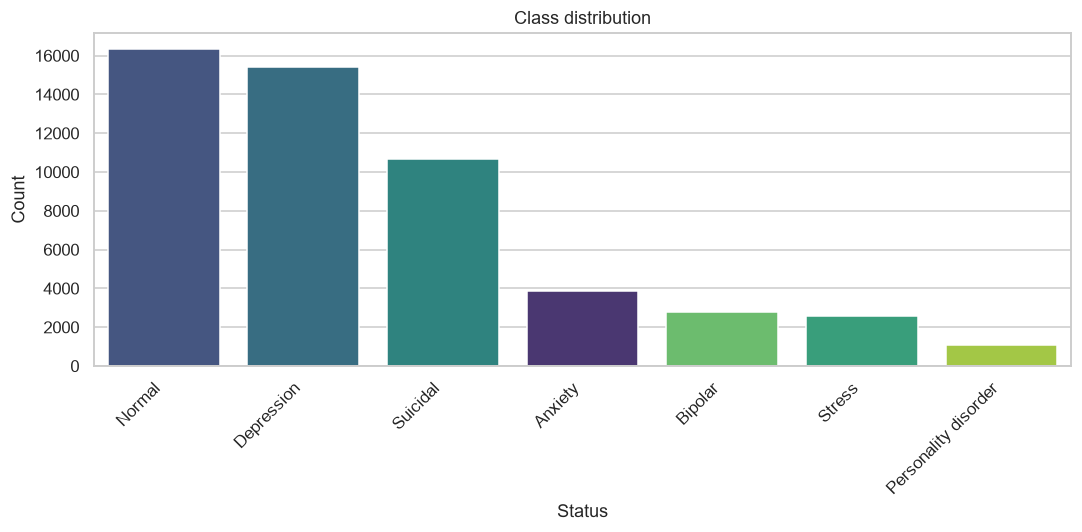

,Count,Percentage
status,,
Normal,16343,31.02
Depression,15404,29.24
Suicidal,10652,20.22
Anxiety,3841,7.29
Bipolar,2777,5.27
Stress,2587,4.91
Personality disorder,1077,2.04


Majority class share: 0.3102
Imbalance ratio     : 15.2 to 1


In [9]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x="status",
    hue="status",
    order=df["status"].value_counts().index,
    palette="viridis",
    legend=False,
)
plt.title("Class distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUT / "figures" / "class_distribution.png", bbox_inches="tight")
plt.show()

class_counts = df["status"].value_counts()
class_percent = df["status"].value_counts(normalize=True) * 100

balance_df = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percent.round(2),
})
display(balance_df)

majority_share = class_counts.max() / len(df)
imbalance_ratio = class_counts.max() / class_counts.min()

print("Majority class share:", round(majority_share, 4))
print("Imbalance ratio     :", f"{imbalance_ratio:.1f} to 1")

### 2.3 Statement length by class

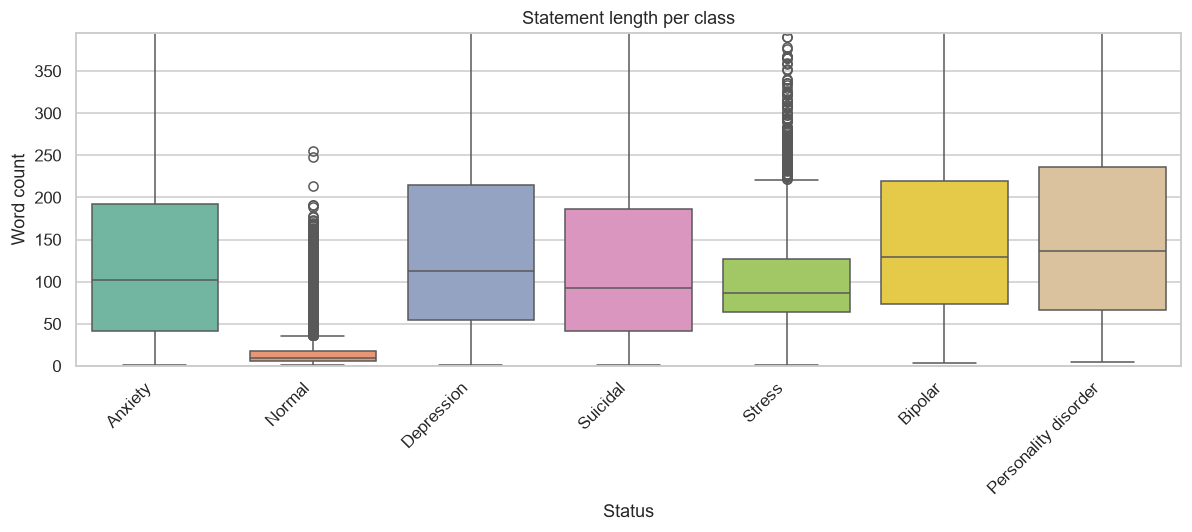

Length statistics per class:


,median,mean,std
status,,,
Anxiety,102.0,143.8,152.6
Bipolar,129.0,176.2,176.5
Depression,113.0,168.0,188.2
Normal,10.0,17.2,22.8
Personality disorder,137.0,179.3,221.9
Stress,87.0,114.6,105.9
Suicidal,92.0,146.4,187.0


In [10]:
df["word_count"] = df["statement"].astype(str).str.split().str.len()

plt.figure(figsize=(11, 5))
sns.boxplot(data=df, x="status", y="word_count", hue="status", palette="Set2", legend=False)
plt.title("Statement length per class")
plt.xlabel("Status")
plt.ylabel("Word count")
plt.ylim(0, df["word_count"].quantile(0.95))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUT / "figures" / "length_by_class.png", bbox_inches="tight")
plt.show()

length_stats = df.groupby("status")["word_count"].agg(["median", "mean", "std"]).round(1)
print("Length statistics per class:")
display(length_stats)

### 2.4 Duplicate audit

In [11]:
df["clean_statement"] = (
    df["statement"].astype(str)
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

duplicate_mask = df.duplicated(subset=["clean_statement"])
duplicate_count = int(duplicate_mask.sum())
duplicate_percent = duplicate_count / len(df) * 100

print("Total rows           :", len(df))
print("Exact duplicate rows :", duplicate_count)
print("Percentage duplicated:", f"{duplicate_percent:.2f}%")

if duplicate_count > 0:
    all_duplicates = df[df.duplicated(subset=["clean_statement"], keep=False)]
    labels_per_text = all_duplicates.groupby("clean_statement")["status"].nunique()
    conflicting = int((labels_per_text > 1).sum())

    print()
    print("Distinct texts appearing with more than one label:", conflicting)
    print()
    print("Example duplicate rows:")
    display(all_duplicates.sort_values("clean_statement")[["status", "statement"]].head(4))

Total rows           : 52681
Exact duplicate rows : 1637
Percentage duplicated: 3.11%

Distinct texts appearing with more than one label: 22

Example duplicate rows:


,status,statement
51720,Anxiety,"""Buy Friends"" comment? My mother doesn't have friends. She said if she won a lot of money it would be easy to 'buy f..."
52666,Anxiety,"""Buy Friends"" comment? My mother doesn't have friends. She said if she won a lot of money it would be easy to 'buy f..."
48401,Stress,"""Desk Toys for Your Stressful Day!"" \n\nDesk toys are the perfect way to relieve stress during a tough day at work...."
49217,Stress,"""Desk Toys for Your Stressful Day!"" \n\nDesk toys are the perfect way to relieve stress during a tough day at work...."


### 2.5 Vocabulary and frequent tokens

In [12]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer()
count_vectorizer.fit(df["clean_statement"])
count_vocab_size = len(count_vectorizer.vocabulary_)

print("Unique word types in the corpus:", count_vocab_size)

count_matrix = count_vectorizer.transform(df["clean_statement"])
word_totals = np.asarray(count_matrix.sum(axis=0)).ravel()

word_freq = pd.DataFrame({
    "word": count_vectorizer.get_feature_names_out(),
    "freq": word_totals,
})
word_freq = word_freq.sort_values("freq", ascending=False)

print()
print("Twenty most frequent words:")
display(word_freq.head(20))

Unique word types in the corpus: 59234

Twenty most frequent words:


,word,freq
52913,to,197887
4110,and,176353
51998,the,127413
35170,my,120189
28072,it,96027
37093,of,85012
36514,not,76544
32903,me,73208
27971,is,72457
24169,have,70002


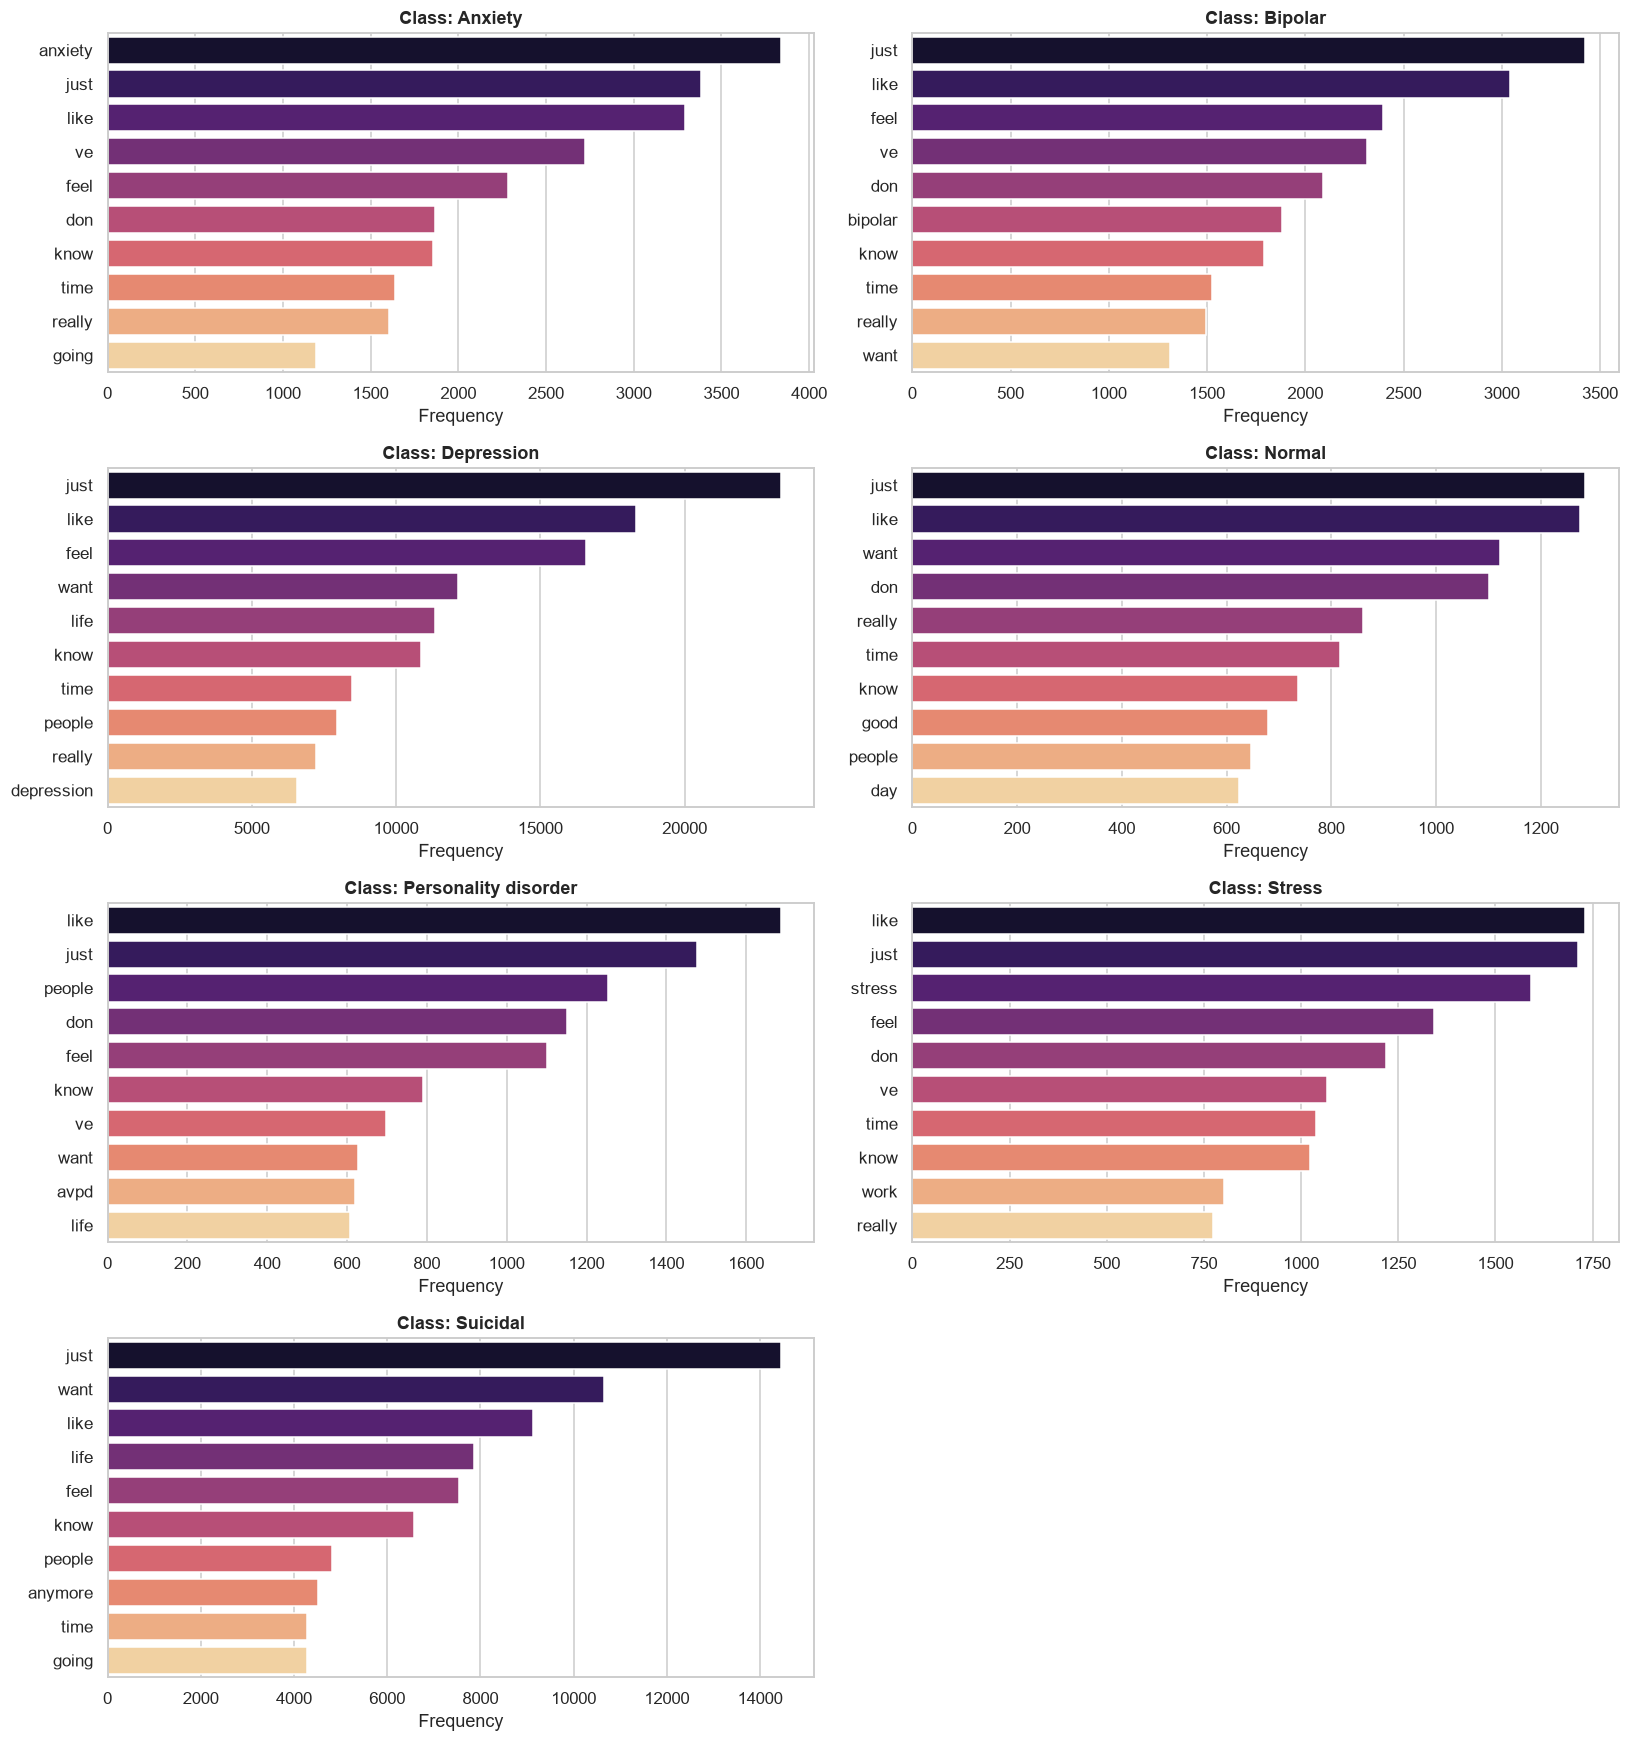

In [13]:
class_vectorizer = CountVectorizer(stop_words="english")
eda_classes = sorted(df["status"].unique())

n_rows = int(np.ceil(len(eda_classes) / 2))
fig, axes = plt.subplots(nrows=n_rows, ncols=2, figsize=(15, 16))
axes = np.array(axes).flatten()

for i, class_name in enumerate(eda_classes):
    class_texts = df.loc[df["status"] == class_name, "clean_statement"]
    class_matrix = class_vectorizer.fit_transform(class_texts)
    class_totals = np.asarray(class_matrix.sum(axis=0)).ravel()

    class_freq = pd.DataFrame({
        "word": class_vectorizer.get_feature_names_out(),
        "freq": class_totals,
    })
    class_freq = class_freq.sort_values("freq", ascending=False).head(10)

    sns.barplot(data=class_freq, x="freq", y="word", hue="word",
                ax=axes[i], palette="magma", legend=False)
    axes[i].set_title(f"Class: {class_name}", fontweight="bold")
    axes[i].set_xlabel("Frequency")
    axes[i].set_ylabel("")

for j in range(len(eda_classes), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(OUT / "figures" / "top_tokens_per_class.png", bbox_inches="tight")
plt.show()

## 3. Deduplication, leakage audit and splitting

In [14]:
df_clean = df.drop_duplicates(subset=["clean_statement"], keep="first").copy()
df_clean = df_clean.reset_index(drop=True)

print("Rows before deduplication:", len(df))
print("Rows after deduplication :", len(df_clean))
print("Rows removed             :", len(df) - len(df_clean))

if CONFIG["sample_n"] is not None and CONFIG["sample_n"] < len(df_clean):
    target_fraction = CONFIG["sample_n"] / len(df_clean)
    sampled_parts = []
    for class_name, group in df_clean.groupby("status"):
        n_keep = max(30, int(len(group) * target_fraction))
        sampled_parts.append(group.sample(n_keep, random_state=SEED))
    df_clean = pd.concat(sampled_parts).reset_index(drop=True)
    print()
    print("FAST_MODE subsample applied. Rows now:", len(df_clean))

Rows before deduplication: 52681
Rows after deduplication : 51044
Rows removed             : 1637


### 3.1 Near duplicate detection

In [15]:
from datasketch import MinHash, MinHashLSH

def make_shingles(text, size=5):
    text = re.sub(r"\s+", " ", text.lower().strip())
    if len(text) <= size:
        return {text} if text else set()
    return {text[i:i + size] for i in range(len(text) - size + 1)}

def make_minhash(text, num_perm=64):
    signature = MinHash(num_perm=num_perm)
    for shingle in make_shingles(text):
        signature.update(shingle.encode("utf8"))
    return signature

class UnionFind:
    def __init__(self, size):
        self.parent = list(range(size))

    def find(self, item):
        while self.parent[item] != item:
            self.parent[item] = self.parent[self.parent[item]]
            item = self.parent[item]
        return item

    def union(self, a, b):
        root_a = self.find(a)
        root_b = self.find(b)
        if root_a != root_b:
            self.parent[root_b] = root_a

print("Near duplicate helpers ready.")

Near duplicate helpers ready.


In [16]:
if CONFIG["run_near_dup"]:
    start_time = time.time()
    texts = df_clean["clean_statement"].tolist()

    lsh_index = MinHashLSH(threshold=CONFIG["near_dup_thresh"], num_perm=64)
    signatures = []

    for i, text in enumerate(texts):
        signature = make_minhash(text)
        signatures.append(signature)
        lsh_index.insert(str(i), signature)

    union_find = UnionFind(len(texts))
    for i, signature in enumerate(signatures):
        for match in lsh_index.query(signature):
            j = int(match)
            if j != i:
                union_find.union(i, j)

    group_ids = []
    for i in range(len(texts)):
        group_ids.append(union_find.find(i))
    df_clean["group"] = group_ids

    group_sizes = df_clean["group"].value_counts()
    multi_member_rows = int(group_sizes[group_sizes > 1].sum())

    print("MinHash finished in", f"{time.time() - start_time:.0f}s")
    print("Distinct groups          :", len(group_sizes))
    print("Rows in multi row groups :", multi_member_rows,
          f"({multi_member_rows / len(df_clean) * 100:.2f}%)")
    print("Largest group size       :", int(group_sizes.max()))
else:
    df_clean["group"] = np.arange(len(df_clean))
    print("Near duplicate audit skipped. Every row is treated as its own group.")

MinHash finished in 168s
Distinct groups          : 50733
Rows in multi row groups : 589 (1.15%)
Largest group size       : 14


### 3.2 Building the splits

In [17]:
from sklearn.model_selection import train_test_split, GroupShuffleSplit

def make_random_split(frame, seed=SEED):
    train_part, temp_part = train_test_split(
        frame, test_size=0.30, stratify=frame["status"], random_state=seed)
    val_part, test_part = train_test_split(
        temp_part, test_size=0.50, stratify=temp_part["status"], random_state=seed)
    return train_part, val_part, test_part

def make_group_split(frame, seed=SEED):
    first_splitter = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, temp_idx = next(first_splitter.split(frame, groups=frame["group"]))
    train_part = frame.iloc[train_idx]
    temp_part = frame.iloc[temp_idx]

    second_splitter = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_idx, test_idx = next(second_splitter.split(temp_part, groups=temp_part["group"]))
    return train_part, temp_part.iloc[val_idx], temp_part.iloc[test_idx]

if SPLIT_PROTOCOL == "B":
    train_df, val_df, test_df = make_group_split(df_clean)
else:
    train_df, val_df, test_df = make_random_split(df_clean)

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

total_rows = len(df_clean)
print("Split protocol:", SPLIT_PROTOCOL)
print(f"Train: {len(train_df):6d} rows ({len(train_df) / total_rows * 100:.1f}%)")
print(f"Val  : {len(val_df):6d} rows ({len(val_df) / total_rows * 100:.1f}%)")
print(f"Test : {len(test_df):6d} rows ({len(test_df) / total_rows * 100:.1f}%)")

Split protocol: A
Train:  35730 rows (70.0%)
Val  :   7657 rows (15.0%)
Test :   7657 rows (15.0%)


In [18]:
train_groups = set(train_df["group"])
leaked_rows = int(test_df["group"].isin(train_groups).sum())
leaked_percent = leaked_rows / len(test_df) * 100

print("Test rows having a near duplicate in the training set:", leaked_rows)
print("As a percentage of the test set:", f"{leaked_percent:.2f}%")

if SPLIT_PROTOCOL == "A" and leaked_rows > 0:
    print()
    print("These rows are contaminated. Re-run with SPLIT_PROTOCOL = 'B' to measure the effect.")

Test rows having a near duplicate in the training set: 60
As a percentage of the test set: 0.78%

These rows are contaminated. Re-run with SPLIT_PROTOCOL = 'B' to measure the effect.


In [19]:
split_indices = {
    "protocol": SPLIT_PROTOCOL,
    "seed": SEED,
    "train_indices": train_df.index.tolist(),
    "val_indices": val_df.index.tolist(),
    "test_indices": test_df.index.tolist(),
}

split_file = OUT / "tables" / f"split_indices_{SPLIT_PROTOCOL}.json"
with open(split_file, "w", encoding="utf-8") as f:
    json.dump(split_indices, f)

assert not (set(train_df.index) & set(val_df.index)), "train and val overlap"
assert not (set(train_df.index) & set(test_df.index)), "train and test overlap"
assert not (set(val_df.index) & set(test_df.index)), "val and test overlap"

print("Split indices saved to", split_file)
print("Verified that the three partitions do not overlap.")

Split indices saved to outputs\tables\split_indices_A.json
Verified that the three partitions do not overlap.


## 4. Text preprocessing

In [20]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

for package in ["stopwords", "wordnet", "omw-1.4"]:
    try:
        nltk.download(package, quiet=True)
    except Exception as error:
        print("Could not download", package, ":", error)

lemmatizer = WordNetLemmatizer()

NEGATION_WORDS = {
    "not", "no", "never", "none", "nothing", "nobody", "cannot",
    "cant", "wont", "dont", "isnt", "arent", "wasnt", "havent",
}

STOP_WORDS = set(stopwords.words("english")) - NEGATION_WORDS

print("Stopwords in use:", len(STOP_WORDS))
print("Negation words kept:", len(NEGATION_WORDS))

Stopwords in use: 196
Negation words kept: 14


In [21]:
def preprocess_text(text, variant="raw"):
    if pd.isna(text):
        return ""

    text = str(text)
    if variant == "raw":
        return text

    text = text.lower()
    if variant == "lower":
        return text

    text = re.sub(r"[^\w\s]", " ", text)
    words = [word for word in text.split() if word not in STOP_WORDS]

    if variant == "lower_punct_stop":
        return " ".join(words)

    if variant == "lemmatize":
        lemmas = [lemmatizer.lemmatize(word) for word in words]
        return " ".join(lemmas)

    return text

example = "I've been SO anxious lately... can't sleep AT ALL, not happy about it."
for variant in ["raw", "lower", "lower_punct_stop", "lemmatize"]:
    print(f"{variant:18s}: {preprocess_text(example, variant)}")

raw               : I've been SO anxious lately... can't sleep AT ALL, not happy about it.
lower             : i've been so anxious lately... can't sleep at all, not happy about it.
lower_punct_stop  : anxious lately sleep not happy
lemmatize         : anxious lately sleep not happy


In [22]:
PREPROCESS_VARIANTS = ["raw", "lower", "lower_punct_stop", "lemmatize"]
SPLIT_FRAMES = [("train", train_df), ("val", val_df), ("test", test_df)]

for name, frame in SPLIT_FRAMES:
    for variant in PREPROCESS_VARIANTS:
        column = f"statement_{variant}"
        frame[column] = frame["statement"].apply(preprocess_text, variant=variant)
    print(name, "processed")

print()
for name, frame in SPLIT_FRAMES:
    empty_rows = int(frame["statement_lemmatize"].str.strip().eq("").sum())
    print(f"{name}: {empty_rows} rows became empty after lemmatization")

display(train_df[["statement", "statement_lower_punct_stop", "statement_lemmatize"]].head(2))

train processed
val processed
test processed

train: 56 rows became empty after lemmatization
val: 14 rows became empty after lemmatization
test: 18 rows became empty after lemmatization


,statement,statement_lower_punct_stop,statement_lemmatize
9561,HeyI think this is going to be sort of long but I need someone who does not know me personally to read my thoughts a...,heyi think going sort long need someone not know personally read thoughts give advice things first think views socie...,heyi think going sort long need someone not know personally read thought give advice thing first think view society ...
9357,"ocd is the worst fuck you ocd i hate you with my whole life why woukd you ruin my life like this I am done, absolute...",ocd worst fuck ocd hate whole life woukd ruin life like done absolutely done,ocd worst fuck ocd hate whole life woukd ruin life like done absolutely done


## 5. Label encoding and evaluation

In [23]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df["status"])
y_val = label_encoder.transform(val_df["status"])
y_test = label_encoder.transform(test_df["status"])

CLASSES = list(label_encoder.classes_)
N_CLASSES = len(CLASSES)

print("Label mapping:")
for index, class_name in enumerate(CLASSES):
    print(f"  {index} -> {class_name}")

print()
print("Number of classes:", N_CLASSES)

Label mapping:
  0 -> Anxiety
  1 -> Bipolar
  2 -> Depression
  3 -> Normal
  4 -> Personality disorder
  5 -> Stress
  6 -> Suicidal

Number of classes: 7


In [24]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

def plot_confusion(model_name, y_true, y_pred):
    matrix = confusion_matrix(y_true, y_pred, labels=range(N_CLASSES))
    row_totals = np.clip(matrix.sum(axis=1, keepdims=True), 1, None)
    matrix_normalised = matrix.astype(float) / row_totals

    fig, axes = plt.subplots(1, 2, figsize=(17, 6))

    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
    axes[0].set_title(f"{model_name} - counts")

    sns.heatmap(matrix_normalised, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
                xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])
    axes[1].set_title(f"{model_name} - row normalised")

    for axis in axes:
        axis.set_ylabel("True label")
        axis.set_xlabel("Predicted label")
        axis.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.savefig(OUT / "figures" / f"cm_{model_name}.png", bbox_inches="tight")
    plt.show()

In [25]:
def evaluate_model(model_name, y_true, y_pred, probabilities=None,
                   family="", notes="", plot=True):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print()
    print("=" * 62)
    print(" ", model_name)
    print("=" * 62)
    print("  Accuracy   :", round(accuracy, 4))
    print("  Macro F1   :", round(macro_f1, 4))
    print("  Weighted F1:", round(weighted_f1, 4))
    print()
    print(classification_report(y_true, y_pred, labels=range(N_CLASSES),
                                target_names=CLASSES, zero_division=0))

    if plot:
        plot_confusion(model_name, y_true, y_pred)

    TEST_PRED[model_name] = y_pred
    if probabilities is not None:
        probabilities = np.asarray(probabilities)
        TEST_PROB[model_name] = probabilities
        np.save(OUT / "predictions" / f"{model_name}_probs.npy", probabilities)

    prediction_table = pd.DataFrame({
        "y_true": y_true,
        "y_pred": y_pred,
        "y_true_label": label_encoder.inverse_transform(y_true),
        "y_pred_label": label_encoder.inverse_transform(y_pred),
    })
    prediction_table.to_csv(OUT / "predictions" / f"{model_name}_predictions.csv", index=False)

    RESULTS.append({
        "Model": model_name,
        "Family": family,
        "Protocol": SPLIT_PROTOCOL,
        "Accuracy": accuracy,
        "Macro_F1": macro_f1,
        "Weighted_F1": weighted_f1,
        "Notes": notes,
    })

    return accuracy, macro_f1

print("Evaluation function ready.")

Evaluation function ready.


## 6. Baseline models

In [26]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier

def surface_features(frame):
    text = frame["statement"].astype(str)
    word_count = text.str.split().str.len().clip(lower=1)

    features = pd.DataFrame({
        "n_chars": text.str.len(),
        "n_words": word_count,
        "avg_word_len": text.str.len() / word_count,
        "n_sentence_marks": text.str.count(r"[.!?]"),
        "n_capitals": text.str.count(r"[A-Z]"),
        "n_digits": text.str.count(r"\d"),
        "n_newlines": text.str.count(r"\n"),
    })
    return features.values

print("Surface feature columns:")
print("  n_chars, n_words, avg_word_len, n_sentence_marks, n_capitals, n_digits, n_newlines")

Surface feature columns:
  n_chars, n_words, avg_word_len, n_sentence_marks, n_capitals, n_digits, n_newlines


In [27]:
dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(np.zeros((len(train_df), 1)), y_train)
dummy_pred = dummy_model.predict(np.zeros((len(test_df), 1)))
majority_accuracy = accuracy_score(y_test, dummy_pred)

set_all_seeds()
notext_model = RandomForestClassifier(
    n_estimators=200, random_state=SEED, class_weight="balanced", n_jobs=-1)
notext_model.fit(surface_features(train_df), y_train)
notext_pred = notext_model.predict(surface_features(test_df))
notext_accuracy = accuracy_score(y_test, notext_pred)

print("Majority class accuracy      :", round(majority_accuracy, 4))
print("No text baseline accuracy    :", round(notext_accuracy, 4))
print("Lift over the majority class :", round(notext_accuracy - majority_accuracy, 4))
print()
print("This much of the task is solvable from formatting alone,")
print("with no access to the words the person actually wrote.")

RESULTS.append({
    "Model": "Baseline_Majority", "Family": "Baseline", "Protocol": SPLIT_PROTOCOL,
    "Accuracy": majority_accuracy,
    "Macro_F1": f1_score(y_test, dummy_pred, average="macro", zero_division=0),
    "Weighted_F1": f1_score(y_test, dummy_pred, average="weighted", zero_division=0),
    "Notes": "predicts the most frequent class",
})

RESULTS.append({
    "Model": "Baseline_NoText", "Family": "Baseline", "Protocol": SPLIT_PROTOCOL,
    "Accuracy": notext_accuracy,
    "Macro_F1": f1_score(y_test, notext_pred, average="macro", zero_division=0),
    "Weighted_F1": f1_score(y_test, notext_pred, average="weighted", zero_division=0),
    "Notes": "length and punctuation features, no words",
})

Majority class accuracy      : 0.3138
No text baseline accuracy    : 0.5599
Lift over the majority class : 0.246

This much of the task is solvable from formatting alone,
with no access to the words the person actually wrote.


## 7. TF-IDF and classical machine learning models

### 7.1 TF-IDF representation

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=CONFIG["tfidf_features"],
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)

X_train_tfidf = tfidf.fit_transform(train_df["statement_lemmatize"])
X_val_tfidf = tfidf.transform(val_df["statement_lemmatize"])
X_test_tfidf = tfidf.transform(test_df["statement_lemmatize"])

density = X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])

print("Train matrix:", X_train_tfidf.shape)
print("Val matrix  :", X_val_tfidf.shape)
print("Test matrix :", X_test_tfidf.shape)
print("Sparsity    :", round(1 - density, 4))

Train matrix: (35730, 10000)
Val matrix  : (7657, 10000)
Test matrix : (7657, 10000)
Sparsity    : 0.9952


### 7.2 Hyperparameter tuning

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

def build_linear_svc(**params):
    base_model = LinearSVC(**params)
    return CalibratedClassifierCV(base_model, cv=3)

models_and_configs = {
    "Naive_Bayes": {
        "builder": MultinomialNB,
        "configs": [
            {"alpha": 0.1},
            {"alpha": 0.5},
            {"alpha": 1.0},
        ],
    },
    "Logistic_Regression": {
        "builder": LogisticRegression,
        "configs": [
            {"C": 0.1, "max_iter": 2000, "class_weight": "balanced"},
            {"C": 1.0, "max_iter": 2000, "class_weight": "balanced"},
            {"C": 10.0, "max_iter": 2000, "class_weight": "balanced"},
        ],
    },
    "Random_Forest": {
        "builder": RandomForestClassifier,
        "configs": [
            {"n_estimators": 50, "max_depth": 10, "class_weight": "balanced",
             "random_state": SEED, "n_jobs": -1},
            {"n_estimators": 100, "max_depth": 20, "class_weight": "balanced",
             "random_state": SEED, "n_jobs": -1},
            {"n_estimators": 200, "max_depth": None, "class_weight": "balanced",
             "random_state": SEED, "n_jobs": -1},
        ],
    },
    "Linear_SVC": {
        "builder": build_linear_svc,
        "configs": [
            {"C": 0.1, "class_weight": "balanced", "max_iter": 3000},
            {"C": 1.0, "class_weight": "balanced", "max_iter": 3000},
            {"C": 10.0, "class_weight": "balanced", "max_iter": 3000},
        ],
    },
}

total_runs = sum(len(info["configs"]) for info in models_and_configs.values())
print("Classical models to train:", list(models_and_configs.keys()))
print("Total tuning runs        :", total_runs)

Classical models to train: ['Naive_Bayes', 'Logistic_Regression', 'Random_Forest', 'Linear_SVC']
Total tuning runs        : 12


In [30]:
classical_tuning = []
best_classical = {}

print("Tuning classical models. Selection is on validation macro F1.")
print()

for model_name, info in models_and_configs.items():
    best_score = -1.0
    best_config = None
    best_model = None

    for i, config in enumerate(info["configs"]):
        set_all_seeds()
        start_time = time.time()

        model = info["builder"](**config)
        model.fit(X_train_tfidf, y_train)

        val_pred = model.predict(X_val_tfidf)
        val_f1 = f1_score(y_val, val_pred, average="macro", zero_division=0)
        elapsed = time.time() - start_time

        classical_tuning.append({
            "Model": model_name,
            "Config_ID": i + 1,
            "Parameters": str(config),
            "Val_Macro_F1": val_f1,
            "Seconds": round(elapsed, 1),
        })

        print(f"  {model_name:20s} config {i + 1}: "
              f"val macro F1 = {val_f1:.4f}  ({elapsed:.0f}s)")

        if val_f1 > best_score:
            best_score = val_f1
            best_config = config
            best_model = model

    best_classical[model_name] = best_model
    print(f"  Best {model_name}: {best_score:.4f} using {best_config}")
    print()

classical_tuning_df = pd.DataFrame(classical_tuning)
classical_tuning_df = classical_tuning_df.sort_values("Val_Macro_F1", ascending=False)
classical_tuning_df.to_csv(OUT / "tables" / "classical_tuning.csv", index=False)
display(classical_tuning_df)

Tuning classical models. Selection is on validation macro F1.

  Naive_Bayes          config 1: val macro F1 = 0.5577  (0s)
  Naive_Bayes          config 2: val macro F1 = 0.5184  (0s)
  Naive_Bayes          config 3: val macro F1 = 0.4780  (0s)
  Best Naive_Bayes: 0.5577 using {'alpha': 0.1}

  Logistic_Regression  config 1: val macro F1 = 0.6449  (1s)
  Logistic_Regression  config 2: val macro F1 = 0.6906  (2s)
  Logistic_Regression  config 3: val macro F1 = 0.6851  (4s)
  Best Logistic_Regression: 0.6906 using {'C': 1.0, 'max_iter': 2000, 'class_weight': 'balanced'}

  Random_Forest        config 1: val macro F1 = 0.5319  (0s)
  Random_Forest        config 2: val macro F1 = 0.6029  (1s)
  Random_Forest        config 3: val macro F1 = 0.6466  (11s)
  Best Random_Forest: 0.6466 using {'n_estimators': 200, 'max_depth': None, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}

  Linear_SVC           config 1: val macro F1 = 0.6914  (2s)
  Linear_SVC           config 2: val ma

,Model,Config_ID,Parameters,Val_Macro_F1,Seconds
9,Linear_SVC,1,"{'C': 0.1, 'class_weight': 'balanced', 'max_iter': 3000}",0.691430,1.6
4,Logistic_Regression,2,"{'C': 1.0, 'max_iter': 2000, 'class_weight': 'balanced'}",0.690592,1.9
5,Logistic_Regression,3,"{'C': 10.0, 'max_iter': 2000, 'class_weight': 'balanced'}",0.685145,4.3
10,Linear_SVC,2,"{'C': 1.0, 'class_weight': 'balanced', 'max_iter': 3000}",0.680026,2.3
8,Random_Forest,3,"{'n_estimators': 200, 'max_depth': None, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}",0.646569,10.8
3,Logistic_Regression,1,"{'C': 0.1, 'max_iter': 2000, 'class_weight': 'balanced'}",0.644880,0.9
11,Linear_SVC,3,"{'C': 10.0, 'class_weight': 'balanced', 'max_iter': 3000}",0.643212,5.4
7,Random_Forest,2,"{'n_estimators': 100, 'max_depth': 20, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}",0.602921,0.6
0,Naive_Bayes,1,{'alpha': 0.1},0.557652,0.0
6,Random_Forest,1,"{'n_estimators': 50, 'max_depth': 10, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}",0.531861,0.2


### 7.3 Test set evaluation


  Naive_Bayes
  Accuracy   : 0.6811
  Macro F1   : 0.5494
  Weighted F1: 0.6731

                      precision    recall  f1-score   support

             Anxiety       0.75      0.67      0.70       542
             Bipolar       0.79      0.57      0.66       375
          Depression       0.53      0.76      0.63      2263
              Normal       0.87      0.81      0.84      2403
Personality disorder       0.80      0.09      0.16       134
              Stress       0.71      0.14      0.24       344
            Suicidal       0.67      0.57      0.62      1596

            accuracy                           0.68      7657
           macro avg       0.73      0.52      0.55      7657
        weighted avg       0.71      0.68      0.67      7657



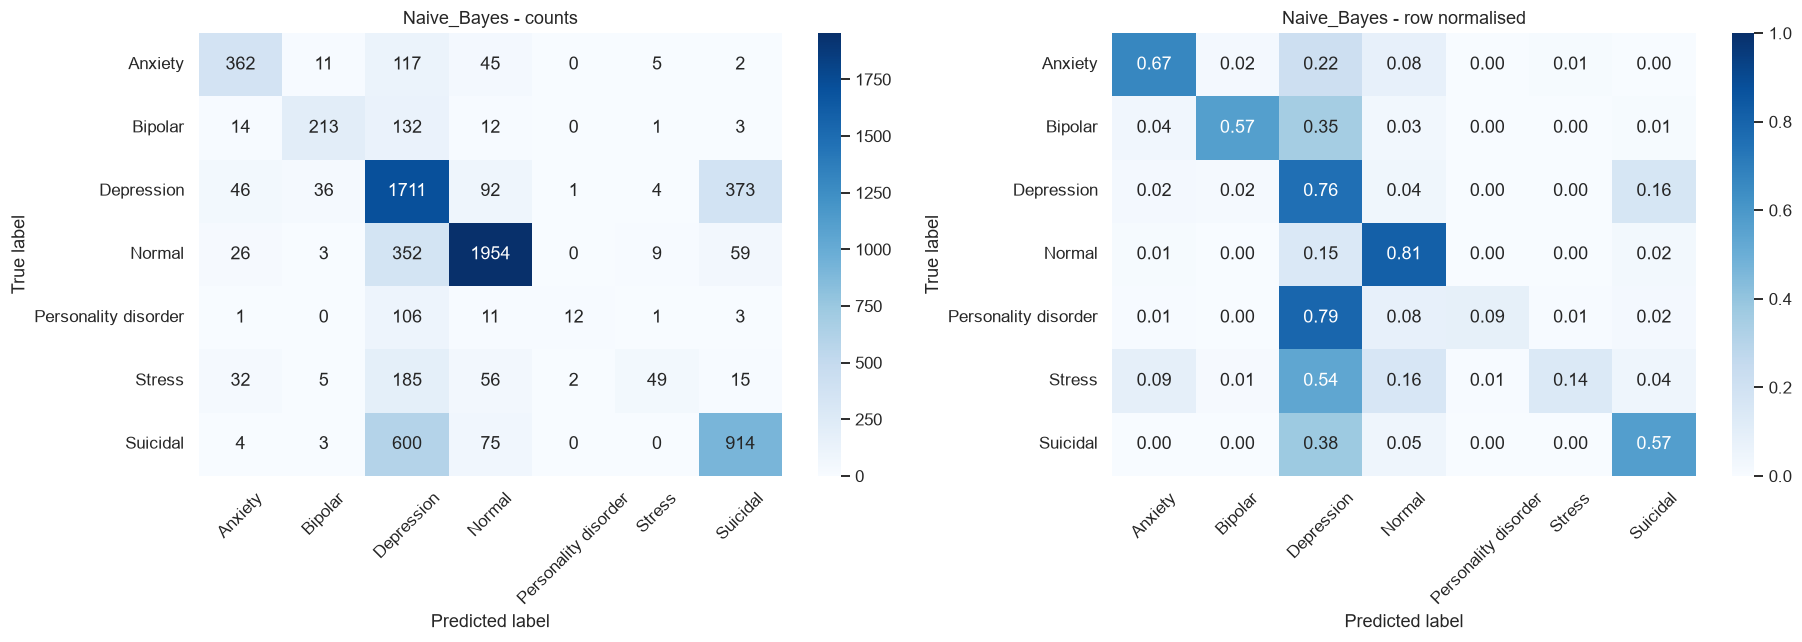


  Logistic_Regression
  Accuracy   : 0.7468
  Macro F1   : 0.6847
  Weighted F1: 0.7472

                      precision    recall  f1-score   support

             Anxiety       0.73      0.81      0.77       542
             Bipolar       0.72      0.78      0.75       375
          Depression       0.76      0.60      0.67      2263
              Normal       0.89      0.92      0.90      2403
Personality disorder       0.43      0.59      0.50       134
              Stress       0.43      0.64      0.52       344
            Suicidal       0.66      0.70      0.68      1596

            accuracy                           0.75      7657
           macro avg       0.66      0.72      0.68      7657
        weighted avg       0.76      0.75      0.75      7657



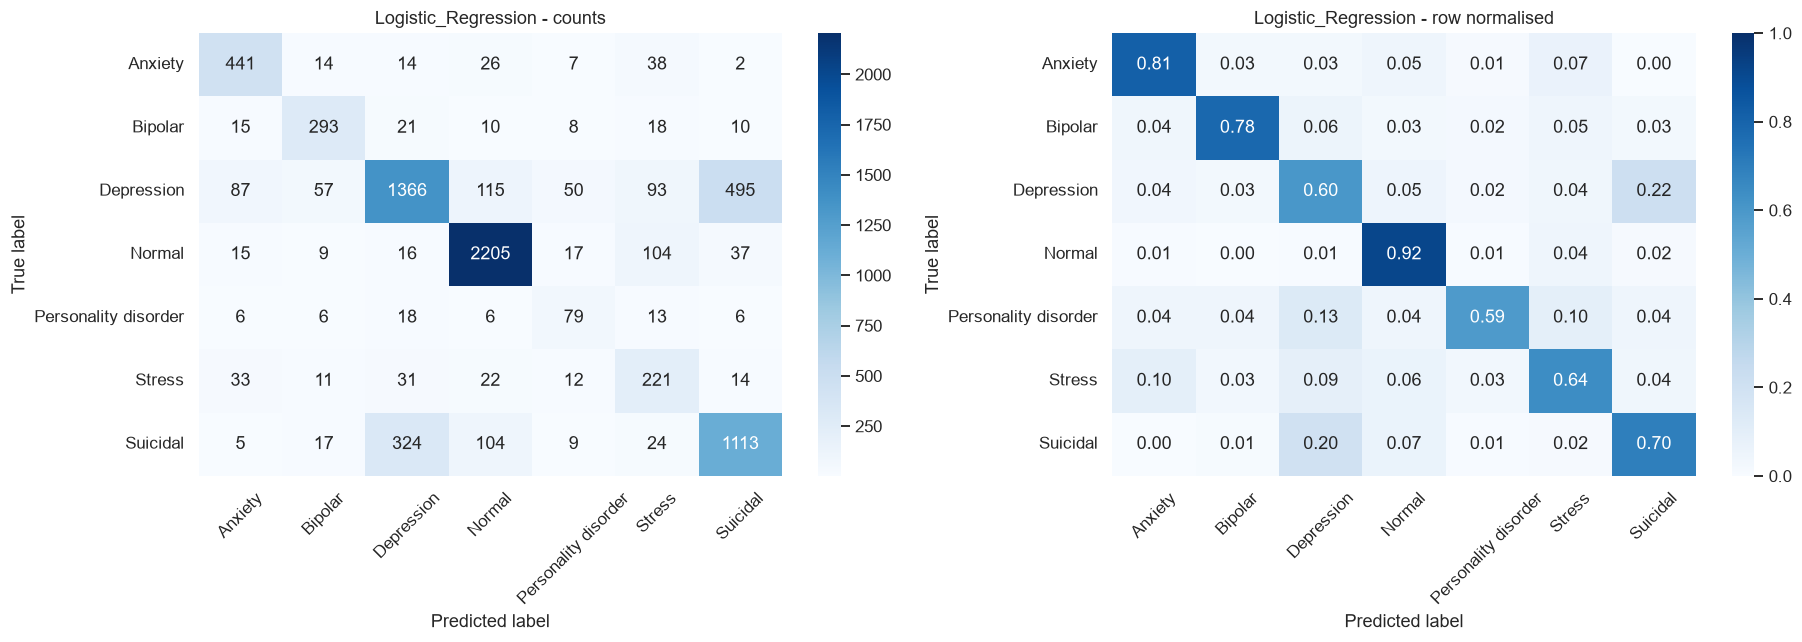


  Random_Forest
  Accuracy   : 0.7239
  Macro F1   : 0.629
  Weighted F1: 0.7138

                      precision    recall  f1-score   support

             Anxiety       0.70      0.78      0.73       542
             Bipolar       0.79      0.69      0.73       375
          Depression       0.67      0.63      0.64      2263
              Normal       0.84      0.94      0.89      2403
Personality disorder       0.94      0.24      0.38       134
              Stress       0.68      0.27      0.38       344
            Suicidal       0.62      0.66      0.64      1596

            accuracy                           0.72      7657
           macro avg       0.75      0.60      0.63      7657
        weighted avg       0.72      0.72      0.71      7657



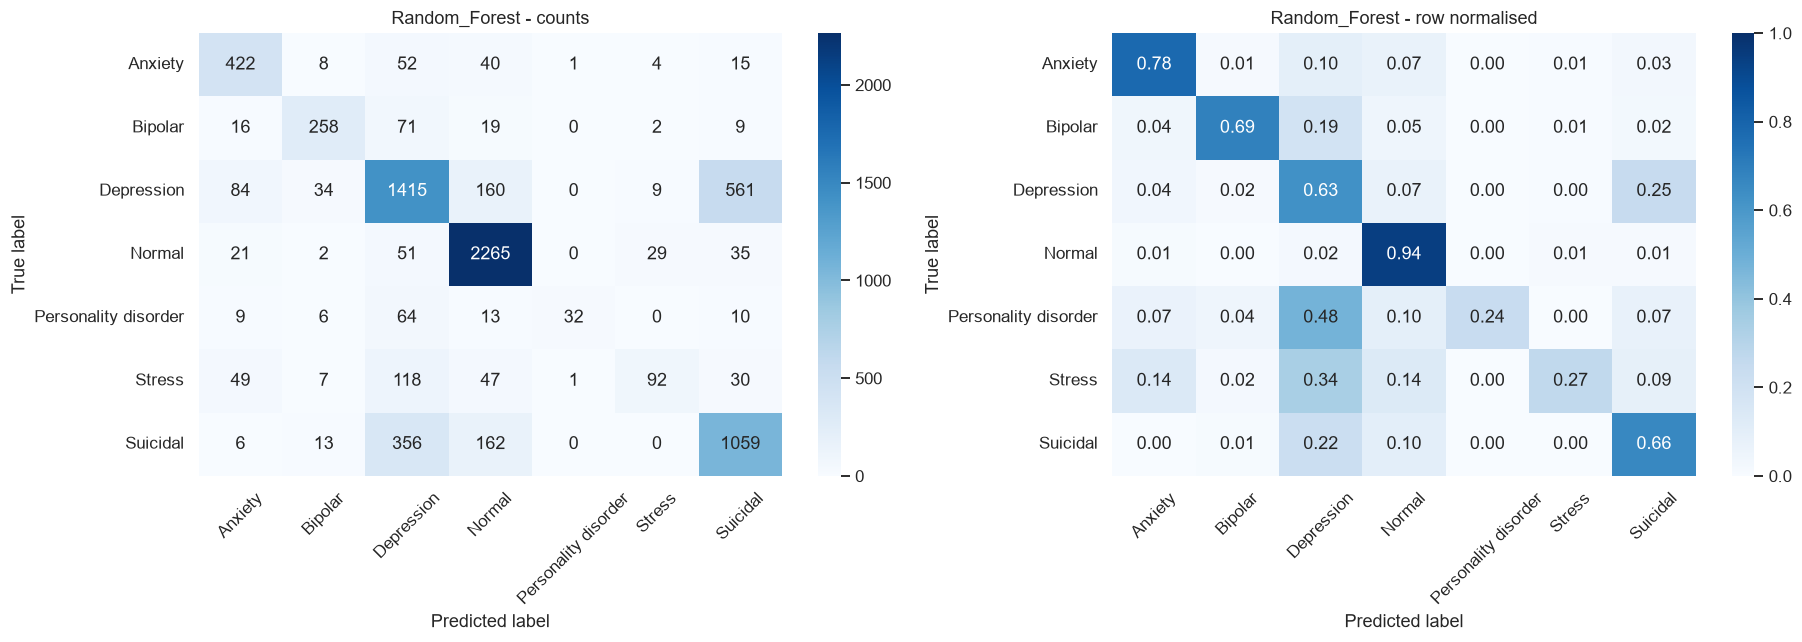


  Linear_SVC
  Accuracy   : 0.7583
  Macro F1   : 0.6847
  Weighted F1: 0.7512

                      precision    recall  f1-score   support

             Anxiety       0.79      0.75      0.77       542
             Bipolar       0.84      0.71      0.77       375
          Depression       0.68      0.73      0.70      2263
              Normal       0.85      0.95      0.90      2403
Personality disorder       0.86      0.36      0.51       134
              Stress       0.69      0.36      0.48       344
            Suicidal       0.70      0.64      0.67      1596

            accuracy                           0.76      7657
           macro avg       0.77      0.64      0.68      7657
        weighted avg       0.76      0.76      0.75      7657



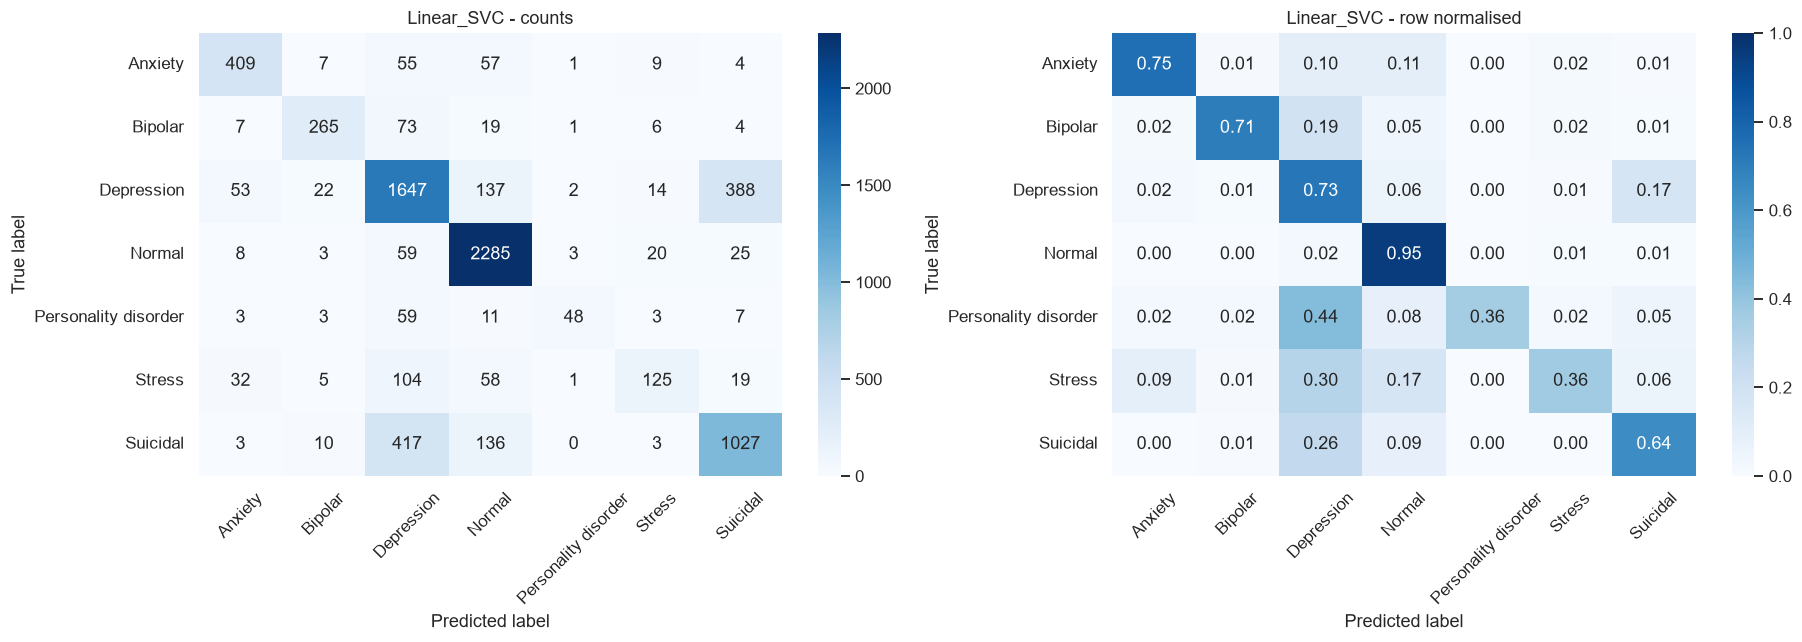

In [31]:
for model_name, model in best_classical.items():
    test_pred = model.predict(X_test_tfidf)

    if hasattr(model, "predict_proba"):
        test_probs = model.predict_proba(X_test_tfidf)
    else:
        test_probs = None

    evaluate_model(model_name, y_test, test_pred, test_probs, family="Classical")

### 7.4 Most informative features

The Logistic Regression coefficients show which terms the model relies on for each class. This
is the cheapest way to check whether the model is using symptom vocabulary or has instead
latched onto platform artifacts such as URL fragments.

In [32]:
logreg_model = best_classical["Logistic_Regression"]
feature_names = np.array(tfidf.get_feature_names_out())

feature_rows = []
for class_index, class_name in enumerate(CLASSES):
    coefficients = logreg_model.coef_[class_index]
    top_indices = np.argsort(coefficients)[-12:][::-1]
    feature_rows.append({
        "Class": class_name,
        "Top weighted features": ", ".join(feature_names[top_indices]),
    })

top_features_df = pd.DataFrame(feature_rows)
top_features_df.to_csv(OUT / "tables" / "top_features_per_class.csv", index=False)

pd.set_option("display.max_colwidth", 200)
display(top_features_df)
pd.set_option("display.max_colwidth", 120)

,Class,Top weighted features
0,Anxiety,"anxiety, restless, anxious, nervous, worried, worry, cancer, restlessness, health anxiety, health, freaking, worrying"
1,Bipolar,"bipolar, manic, med, episode, mania, hypomanic, lamictal, lithium, stable, bp, seroquel, mood"
2,Depression,"depression, wa, cannot, depressed, not know, not, ha, doe, not want, life, pression, le"
3,Normal,"wa, url, ha, ðÿ, twitter, quot, eid, yes, holiday, mutual, jyp, raya"
4,Personality disorder,"avpd, avoidant, people, avoid, social, avoidance, avoiding, person, disorder, pretend, shame, anyone"
5,Stress,"stress, stressed, ptsd, boyfriend, tl dr, tl, happened, dr, abuse, stressing, pay, flashback"
6,Suicidal,"cannot, suicide, suicidal, not know, not, kill, not want, die, http co, goodbye, rt, end"


## 8. Word embeddings and recurrent models

### 8.1 Building the sequence vocabulary

In [33]:
TEXT_COLUMN = CONFIG["text_col"]
MAX_LEN = CONFIG["max_len"]
PAD_INDEX = 0
OOV_INDEX = 1

word_counter = Counter()
for text in train_df[TEXT_COLUMN]:
    word_counter.update(str(text).split())

word2idx = {"<PAD>": PAD_INDEX, "<OOV>": OOV_INDEX}
for word, count in word_counter.most_common(CONFIG["seq_vocab"] - 2):
    word2idx[word] = len(word2idx)

seq_vocab_size = len(word2idx)

print("Word types in the training split:", len(word_counter))
print("Sequence vocabulary size        :", seq_vocab_size)

Word types in the training split: 111050
Sequence vocabulary size        : 20000


In [34]:
def encode_texts(texts, max_len):
    encoded = []
    for text in texts:
        tokens = str(text).split()[:max_len]
        ids = []
        for token in tokens:
            ids.append(word2idx.get(token, OOV_INDEX))
        if len(ids) == 0:
            ids = [OOV_INDEX]
        encoded.append(ids)
    return encoded

train_sequences = encode_texts(train_df[TEXT_COLUMN], MAX_LEN)
val_sequences = encode_texts(val_df[TEXT_COLUMN], MAX_LEN)
test_sequences = encode_texts(test_df[TEXT_COLUMN], MAX_LEN)

sequence_lengths = np.array([len(sequence) for sequence in train_sequences])
original_lengths = np.array([len(str(text).split()) for text in train_df[TEXT_COLUMN]])
truncated_share = np.mean(original_lengths > MAX_LEN) * 100

print("Median token length:", int(np.median(sequence_lengths)))
print("90th percentile    :", int(np.percentile(sequence_lengths, 90)))
print("99th percentile    :", int(np.percentile(sequence_lengths, 99)))
print("Share truncated at", MAX_LEN, "tokens:", f"{truncated_share:.1f}%")

Median token length: 61
90th percentile    : 128
99th percentile    : 128
Share truncated at 128 tokens: 28.9%


### 8.2 Datasets and loaders

In [35]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class SequenceDataset(Dataset):
    def __init__(self, sequences, labels, max_len):
        self.ids = np.zeros((len(sequences), max_len), dtype=np.int64)
        self.lengths = np.zeros(len(sequences), dtype=np.int64)

        for i, sequence in enumerate(sequences):
            self.ids[i, :len(sequence)] = sequence
            self.lengths[i] = len(sequence)

        self.labels = np.asarray(labels, dtype=np.int64)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return (
            torch.from_numpy(self.ids[index]),
            torch.tensor(self.lengths[index]),
            torch.tensor(self.labels[index]),
        )

train_dataset = SequenceDataset(train_sequences, y_train, MAX_LEN)
val_dataset = SequenceDataset(val_sequences, y_val, MAX_LEN)
test_dataset = SequenceDataset(test_sequences, y_test, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=CONFIG["rnn_batch"],
                          shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)

print("Training batches  :", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches      :", len(test_loader))

Training batches  : 559
Validation batches: 30
Test batches      : 30


### 8.3 Word2Vec embeddings

In [36]:
from gensim.models import Word2Vec

set_all_seeds()
start_time = time.time()

training_sentences = [str(text).split() for text in train_df[TEXT_COLUMN]]
w2v_model = Word2Vec(
    training_sentences,
    vector_size=100,
    window=5,
    min_count=2,
    sg=1,
    workers=4,
    epochs=5,
    seed=SEED,
)

EMBEDDING_DIM = 100
embedding_matrix = np.zeros((seq_vocab_size, EMBEDDING_DIM), dtype=np.float32)

words_found = 0
for word, index in word2idx.items():
    if word in w2v_model.wv:
        embedding_matrix[index] = w2v_model.wv[word]
        words_found += 1

print("Word2Vec trained in", f"{time.time() - start_time:.0f}s")
print("Embedding matrix shape:", embedding_matrix.shape)
print("Vectors found         :", words_found, "of", seq_vocab_size,
      f"({words_found / seq_vocab_size * 100:.1f}%)")

Word2Vec trained in 13s
Embedding matrix shape: (20000, 100)
Vectors found         : 19998 of 20000 (100.0%)


### 8.4 Model definition

In [37]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, n_classes,
                 cell_type="LSTM", bidirectional=False, dropout=0.3,
                 embedding_weights=None, trainable_embedding=True):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=PAD_INDEX)
        if embedding_weights is not None:
            self.embedding.weight.data.copy_(torch.from_numpy(embedding_weights))
        self.embedding.weight.requires_grad = trainable_embedding

        cell_classes = {"RNN": nn.RNN, "GRU": nn.GRU, "LSTM": nn.LSTM}
        self.rnn = cell_classes[cell_type](
            embedding_dim, hidden_size, batch_first=True, bidirectional=bidirectional)

        self.bidirectional = bidirectional
        self.dropout = nn.Dropout(dropout)

        output_size = hidden_size * 2 if bidirectional else hidden_size
        self.fc = nn.Linear(output_size, n_classes)

    def forward(self, ids, lengths):
        embedded = self.embedding(ids)

        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, hidden = self.rnn(packed)

        if isinstance(hidden, tuple):
            hidden = hidden[0]

        if self.bidirectional:
            hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        else:
            hidden = hidden[-1]

        return self.fc(self.dropout(hidden))

print("RNNClassifier defined.")

RNNClassifier defined.


In [38]:
train_class_counts = np.bincount(y_train, minlength=N_CLASSES)
weight_values = len(y_train) / (N_CLASSES * np.clip(train_class_counts, 1, None))
class_weights = torch.tensor(weight_values, dtype=torch.float32, device=DEVICE)

print("Class weights:")
for class_name, weight in zip(CLASSES, weight_values):
    print(f"  {class_name:22s} {weight:.3f}")

Class weights:
  Anxiety                2.019
  Bipolar                2.915
  Depression             0.483
  Normal                 0.455
  Personality disorder   8.154
  Stress                 3.182
  Suicidal               0.685


### 8.5 Training and prediction functions

In [39]:
def predict_probabilities(model, loader):
    model.eval()
    batch_probabilities = []

    with torch.no_grad():
        for ids, lengths, _ in loader:
            logits = model(ids.to(DEVICE), lengths)
            probabilities = torch.softmax(logits.float(), dim=-1)
            batch_probabilities.append(probabilities.cpu().numpy())

    return np.vstack(batch_probabilities)

In [40]:
def train_rnn_model(model, epochs, patience, learning_rate=1e-3, verbose=False):
    model = model.to(DEVICE)

    trainable_parameters = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(trainable_parameters, lr=learning_rate)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    best_f1 = -1.0
    best_state = None
    epochs_without_improvement = 0
    history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for ids, lengths, labels in train_loader:
            ids = ids.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()
            logits = model(ids, lengths)
            loss = criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

            running_loss += loss.item()

        val_pred = predict_probabilities(model, val_loader).argmax(axis=1)
        val_f1 = f1_score(y_val, val_pred, average="macro", zero_division=0)
        average_loss = running_loss / len(train_loader)

        history.append({
            "epoch": epoch + 1,
            "train_loss": average_loss,
            "val_macro_f1": val_f1,
        })

        if verbose:
            print(f"      epoch {epoch + 1}/{epochs} "
                  f"loss={average_loss:.4f} val_f1={val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                if verbose:
                    print("      early stopping")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, best_f1, history

print("Training functions ready.")

Training functions ready.


### 8.6 Hyperparameter tuning

In [41]:
RNN_ARCHITECTURES = [
    ("SimpleRNN", "RNN", False),
    ("GRU", "GRU", False),
    ("LSTM", "LSTM", False),
    ("Bi-SimpleRNN", "RNN", True),
    ("Bi-GRU", "GRU", True),
    ("Bi-LSTM", "LSTM", True),
]

RNN_CONFIGS = [
    ("config 1", {"hidden_size": 32, "dropout": 0.2,
                  "trainable_embedding": True, "learning_rate": 1e-3}),
    ("config 2", {"hidden_size": 64, "dropout": 0.3,
                  "trainable_embedding": True, "learning_rate": 1e-3}),
    ("config 3", {"hidden_size": 128, "dropout": 0.4,
                  "trainable_embedding": False, "learning_rate": 1e-3}),
]

print("Architectures     :", [name for name, _, _ in RNN_ARCHITECTURES])
print("Configs per model :", len(RNN_CONFIGS))
print("Total runs        :", len(RNN_ARCHITECTURES) * len(RNN_CONFIGS))

Architectures     : ['SimpleRNN', 'GRU', 'LSTM', 'Bi-SimpleRNN', 'Bi-GRU', 'Bi-LSTM']
Configs per model : 3
Total runs        : 18


In [42]:
rnn_tuning = []
best_rnn_models = {}
overall_start = time.time()

for display_name, cell_type, bidirectional in RNN_ARCHITECTURES:
    best_score = -1.0
    best_config = None
    best_model = None

    for config_name, params in RNN_CONFIGS:
        set_all_seeds()
        start_time = time.time()

        model = RNNClassifier(
            vocab_size=seq_vocab_size,
            embedding_dim=EMBEDDING_DIM,
            hidden_size=params["hidden_size"],
            n_classes=N_CLASSES,
            cell_type=cell_type,
            bidirectional=bidirectional,
            dropout=params["dropout"],
            embedding_weights=embedding_matrix,
            trainable_embedding=params["trainable_embedding"],
        )

        model, val_f1, history = train_rnn_model(
            model,
            epochs=CONFIG["rnn_epochs"],
            patience=CONFIG["rnn_patience"],
            learning_rate=params["learning_rate"],
        )
        elapsed = time.time() - start_time

        rnn_tuning.append({
            "Model": display_name,
            "Config_ID": config_name,
            "Parameters": str(params),
            "Val_Macro_F1": val_f1,
            "Epochs_Run": len(history),
            "Seconds": round(elapsed, 1),
        })

        print(f"  {display_name:14s} {config_name}: val macro F1 = {val_f1:.4f}  "
              f"({len(history)} epochs, {elapsed:.0f}s)")

        if val_f1 > best_score:
            best_score = val_f1
            best_config = params
            if best_model is not None:
                del best_model
            best_model = model
        else:
            del model

        torch.cuda.empty_cache()

    best_rnn_models[display_name] = best_model
    print(f"  Best {display_name}: {best_score:.4f} using {best_config}")
    print()

print("All recurrent models trained in", f"{(time.time() - overall_start) / 60:.1f} minutes")

rnn_tuning_df = pd.DataFrame(rnn_tuning).sort_values("Val_Macro_F1", ascending=False)
rnn_tuning_df.to_csv(OUT / "tables" / "rnn_tuning.csv", index=False)
display(rnn_tuning_df)

  SimpleRNN      config 1: val macro F1 = 0.4627  (5 epochs, 32s)
  SimpleRNN      config 2: val macro F1 = 0.4786  (5 epochs, 30s)
  SimpleRNN      config 3: val macro F1 = 0.4035  (4 epochs, 20s)
  Best SimpleRNN: 0.4786 using {'hidden_size': 64, 'dropout': 0.3, 'trainable_embedding': True, 'learning_rate': 0.001}

  GRU            config 1: val macro F1 = 0.6715  (7 epochs, 44s)
  GRU            config 2: val macro F1 = 0.6975  (7 epochs, 43s)
  GRU            config 3: val macro F1 = 0.7019  (8 epochs, 38s)
  Best GRU: 0.7019 using {'hidden_size': 128, 'dropout': 0.4, 'trainable_embedding': False, 'learning_rate': 0.001}

  LSTM           config 1: val macro F1 = 0.6627  (8 epochs, 49s)
  LSTM           config 2: val macro F1 = 0.6740  (8 epochs, 49s)
  LSTM           config 3: val macro F1 = 0.6541  (8 epochs, 38s)
  Best LSTM: 0.6740 using {'hidden_size': 64, 'dropout': 0.3, 'trainable_embedding': True, 'learning_rate': 0.001}

  Bi-SimpleRNN   config 1: val macro F1 = 0.5971  (8

,Model,Config_ID,Parameters,Val_Macro_F1,Epochs_Run,Seconds
12,Bi-GRU,config 1,"{'hidden_size': 32, 'dropout': 0.2, 'trainable_embedding': True, 'learning_rate': 0.001}",0.714399,6,60.0
13,Bi-GRU,config 2,"{'hidden_size': 64, 'dropout': 0.3, 'trainable_embedding': True, 'learning_rate': 0.001}",0.710075,7,69.1
14,Bi-GRU,config 3,"{'hidden_size': 128, 'dropout': 0.4, 'trainable_embedding': False, 'learning_rate': 0.001}",0.708440,8,68.2
5,GRU,config 3,"{'hidden_size': 128, 'dropout': 0.4, 'trainable_embedding': False, 'learning_rate': 0.001}",0.701906,8,38.0
4,GRU,config 2,"{'hidden_size': 64, 'dropout': 0.3, 'trainable_embedding': True, 'learning_rate': 0.001}",0.697512,7,43.1
16,Bi-LSTM,config 2,"{'hidden_size': 64, 'dropout': 0.3, 'trainable_embedding': True, 'learning_rate': 0.001}",0.694611,6,59.7
15,Bi-LSTM,config 1,"{'hidden_size': 32, 'dropout': 0.2, 'trainable_embedding': True, 'learning_rate': 0.001}",0.691504,8,82.1
17,Bi-LSTM,config 3,"{'hidden_size': 128, 'dropout': 0.4, 'trainable_embedding': False, 'learning_rate': 0.001}",0.688823,8,68.5
7,LSTM,config 2,"{'hidden_size': 64, 'dropout': 0.3, 'trainable_embedding': True, 'learning_rate': 0.001}",0.673966,8,48.6
3,GRU,config 1,"{'hidden_size': 32, 'dropout': 0.2, 'trainable_embedding': True, 'learning_rate': 0.001}",0.671454,7,44.4


### 8.7 Test set evaluation


  SimpleRNN
  Accuracy   : 0.621
  Macro F1   : 0.4854
  Weighted F1: 0.6337

                      precision    recall  f1-score   support

             Anxiety       0.50      0.66      0.57       542
             Bipolar       0.30      0.30      0.30       375
          Depression       0.61      0.58      0.60      2263
              Normal       0.95      0.82      0.88      2403
Personality disorder       0.15      0.32      0.20       134
              Stress       0.28      0.40      0.33       344
            Suicidal       0.53      0.51      0.52      1596

            accuracy                           0.62      7657
           macro avg       0.47      0.51      0.49      7657
        weighted avg       0.65      0.62      0.63      7657



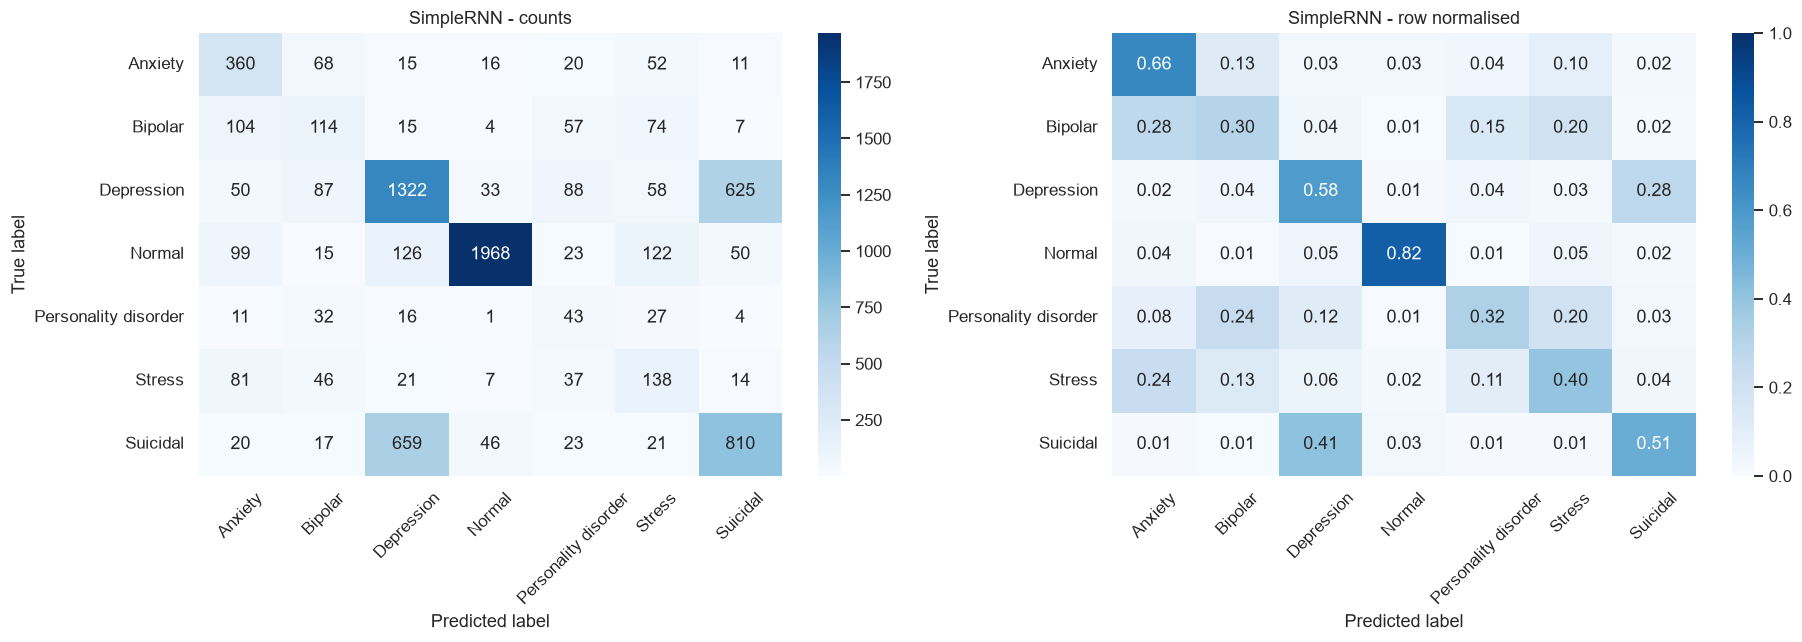


  GRU
  Accuracy   : 0.7609
  Macro F1   : 0.7034
  Weighted F1: 0.7648

                      precision    recall  f1-score   support

             Anxiety       0.78      0.82      0.80       542
             Bipolar       0.70      0.82      0.75       375
          Depression       0.81      0.62      0.70      2263
              Normal       0.94      0.89      0.91      2403
Personality disorder       0.39      0.70      0.50       134
              Stress       0.51      0.65      0.57       344
            Suicidal       0.63      0.77      0.69      1596

            accuracy                           0.76      7657
           macro avg       0.68      0.75      0.70      7657
        weighted avg       0.78      0.76      0.76      7657



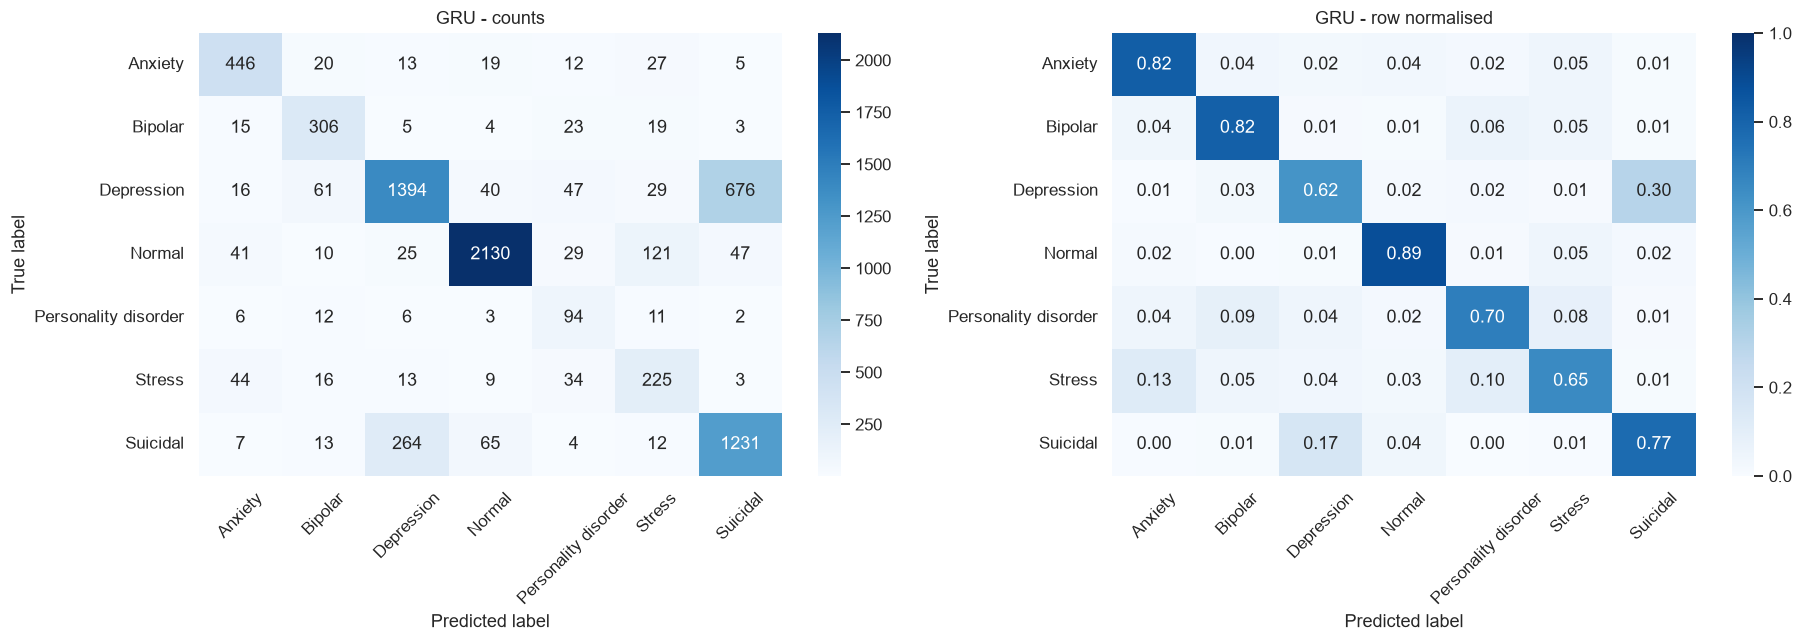


  LSTM
  Accuracy   : 0.7449
  Macro F1   : 0.6665
  Weighted F1: 0.7497

                      precision    recall  f1-score   support

             Anxiety       0.73      0.80      0.76       542
             Bipolar       0.65      0.81      0.72       375
          Depression       0.79      0.59      0.68      2263
              Normal       0.94      0.89      0.92      2403
Personality disorder       0.36      0.45      0.40       134
              Stress       0.40      0.69      0.51       344
            Suicidal       0.63      0.74      0.68      1596

            accuracy                           0.74      7657
           macro avg       0.64      0.71      0.67      7657
        weighted avg       0.77      0.74      0.75      7657



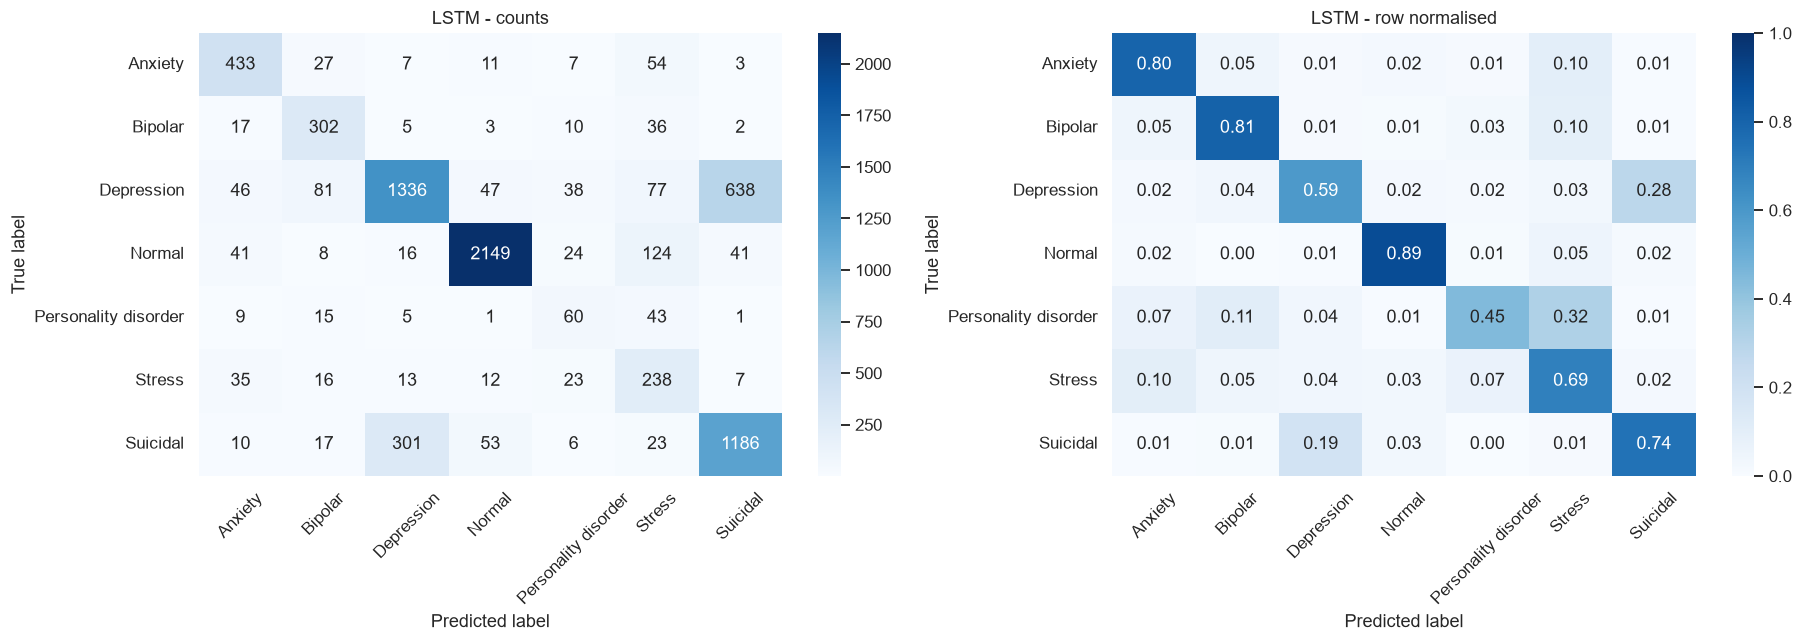


  Bi-SimpleRNN
  Accuracy   : 0.7011
  Macro F1   : 0.6132
  Weighted F1: 0.7029

                      precision    recall  f1-score   support

             Anxiety       0.67      0.82      0.74       542
             Bipolar       0.55      0.77      0.64       375
          Depression       0.64      0.67      0.66      2263
              Normal       0.94      0.85      0.90      2403
Personality disorder       0.34      0.32      0.33       134
              Stress       0.45      0.47      0.46       344
            Suicidal       0.59      0.53      0.56      1596

            accuracy                           0.70      7657
           macro avg       0.60      0.63      0.61      7657
        weighted avg       0.71      0.70      0.70      7657



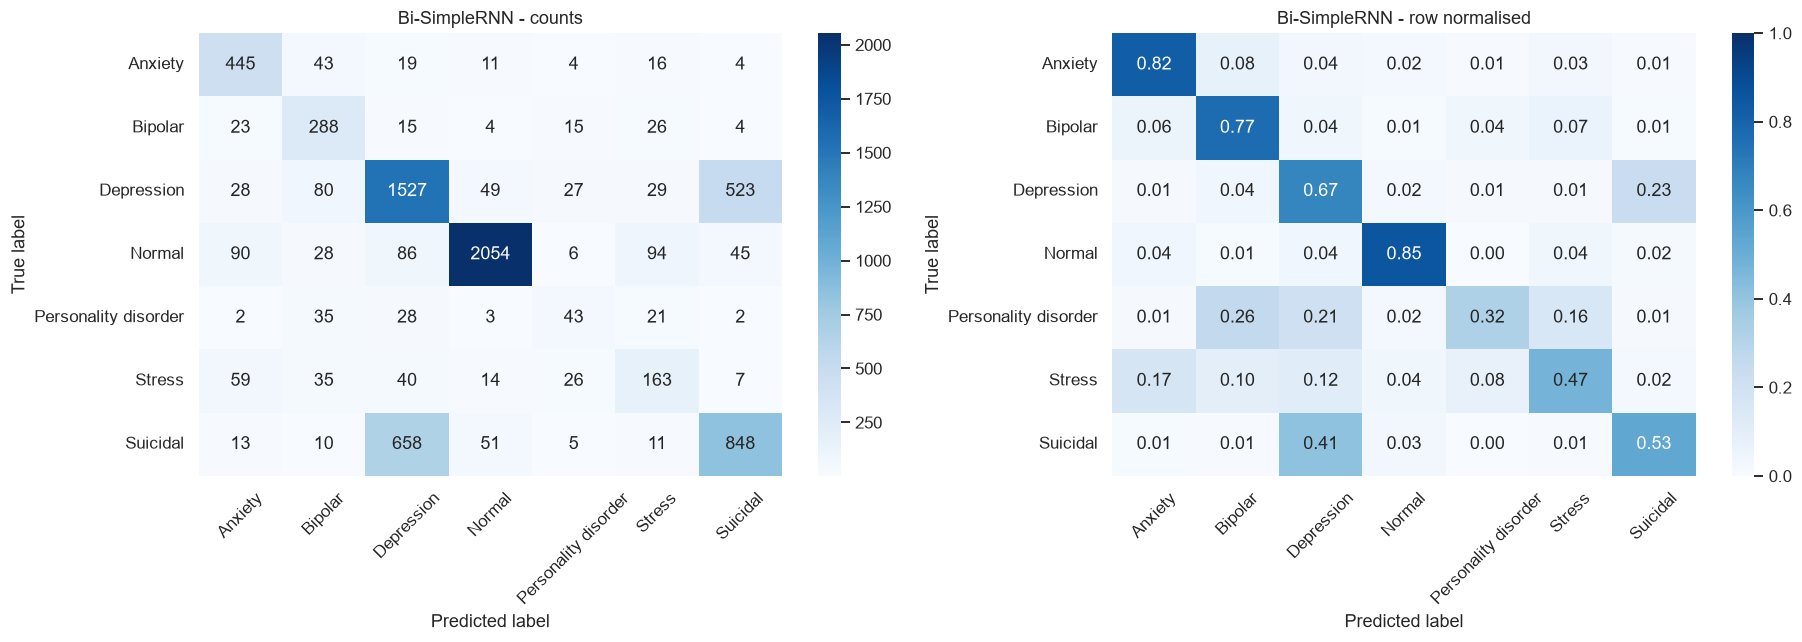


  Bi-GRU
  Accuracy   : 0.7631
  Macro F1   : 0.7097
  Weighted F1: 0.7693

                      precision    recall  f1-score   support

             Anxiety       0.82      0.81      0.81       542
             Bipolar       0.81      0.77      0.79       375
          Depression       0.78      0.66      0.71      2263
              Normal       0.94      0.88      0.91      2403
Personality disorder       0.49      0.55      0.52       134
              Stress       0.41      0.76      0.53       344
            Suicidal       0.65      0.74      0.69      1596

            accuracy                           0.76      7657
           macro avg       0.70      0.74      0.71      7657
        weighted avg       0.79      0.76      0.77      7657



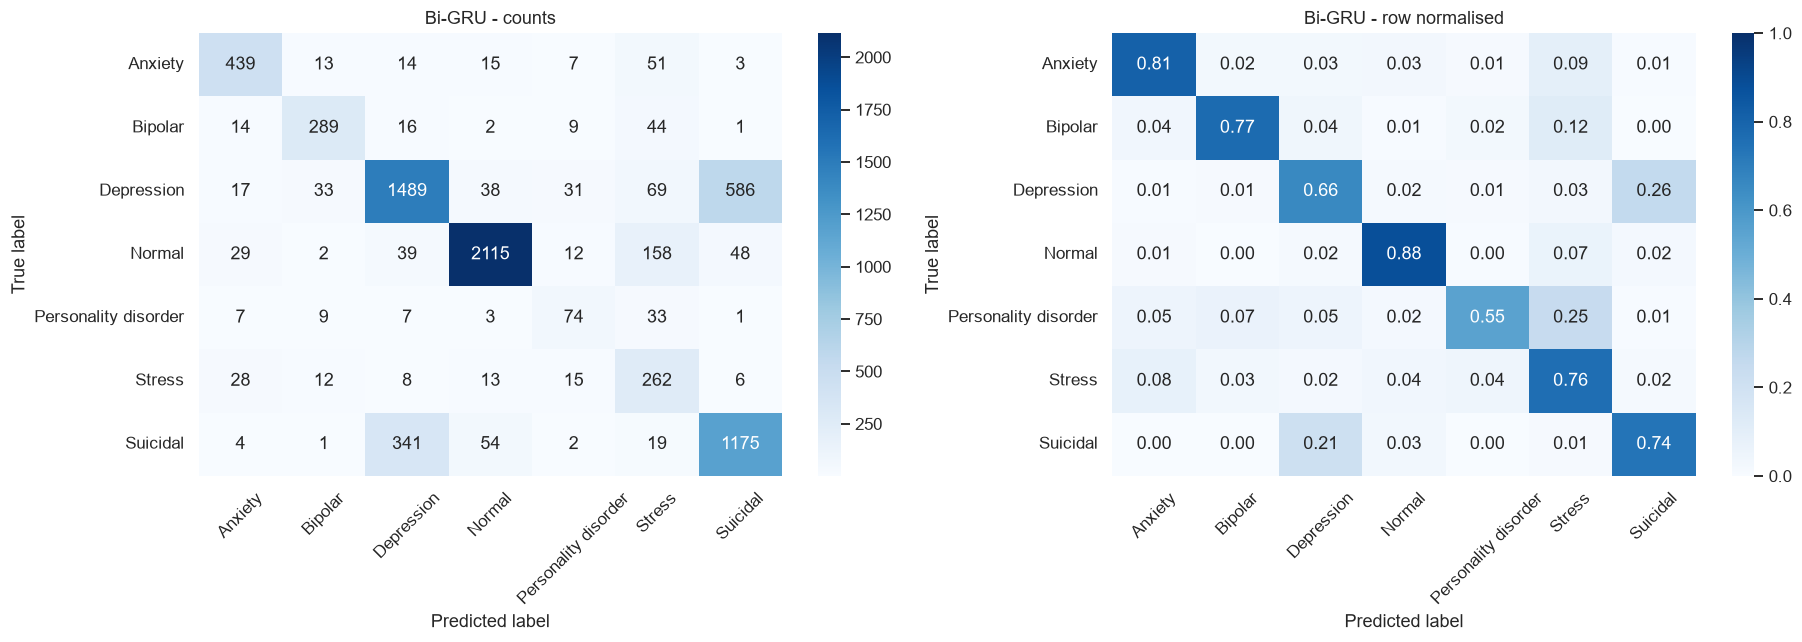


  Bi-LSTM
  Accuracy   : 0.7651
  Macro F1   : 0.7023
  Weighted F1: 0.7695

                      precision    recall  f1-score   support

             Anxiety       0.83      0.77      0.80       542
             Bipolar       0.74      0.79      0.76       375
          Depression       0.77      0.66      0.71      2263
              Normal       0.94      0.91      0.92      2403
Personality disorder       0.38      0.64      0.48       134
              Stress       0.46      0.69      0.55       344
            Suicidal       0.65      0.71      0.68      1596

            accuracy                           0.77      7657
           macro avg       0.68      0.74      0.70      7657
        weighted avg       0.78      0.77      0.77      7657



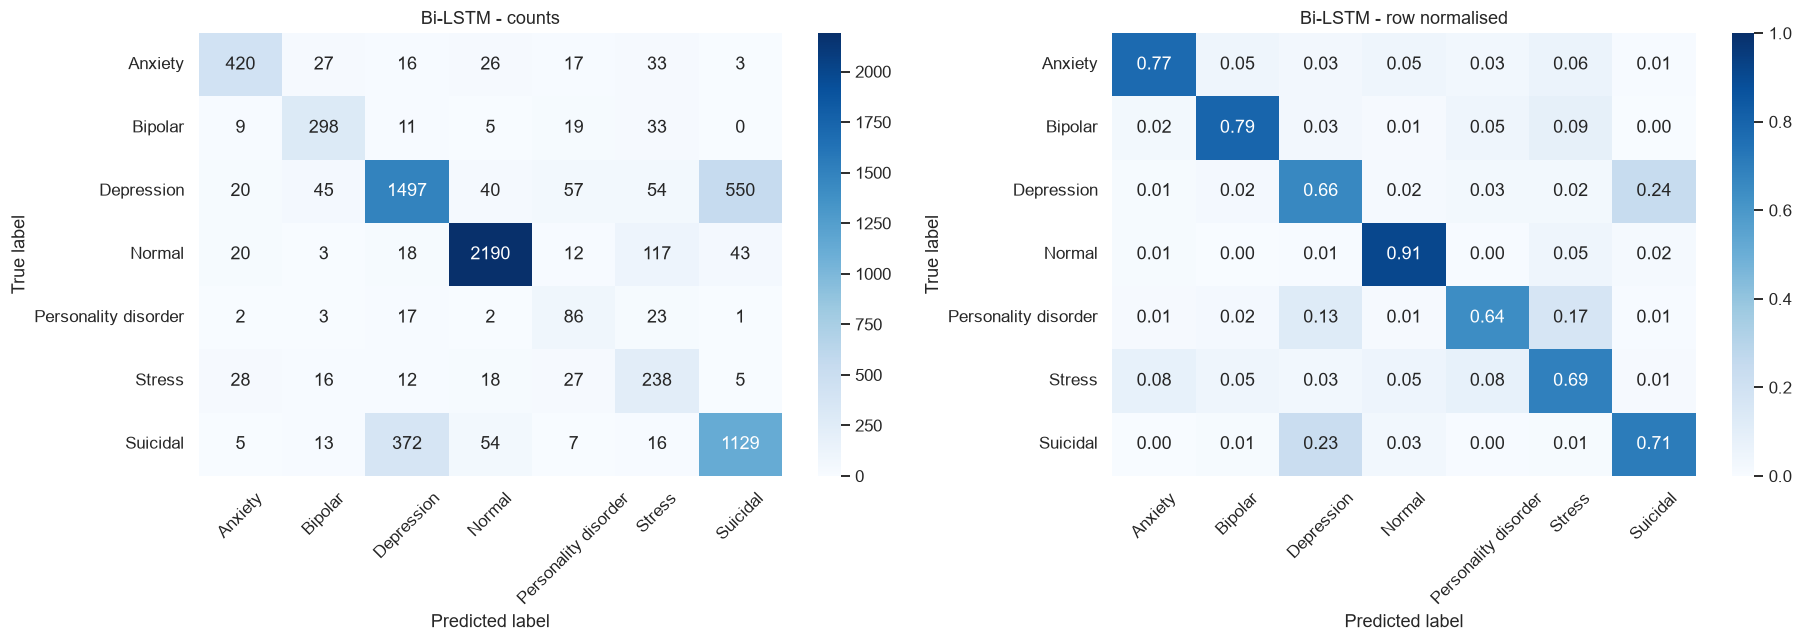

In [43]:
for display_name, model in best_rnn_models.items():
    test_probs = predict_probabilities(model, test_loader)
    test_pred = test_probs.argmax(axis=1)
    evaluate_model(display_name, y_test, test_pred, test_probs, family="Recurrent")

The best recurrent model is saved to disk. The others are released so that the GPU memory is
free for transformer training in the next section.

In [44]:
recurrent_results = [record for record in RESULTS if record["Family"] == "Recurrent"]
best_recurrent = max(recurrent_results, key=lambda record: record["Macro_F1"])
best_recurrent_name = best_recurrent["Model"]

model_path = OUT / "models" / f"best_rnn_{best_recurrent_name}.pt"
torch.save(best_rnn_models[best_recurrent_name].state_dict(), model_path)

for name in list(best_rnn_models.keys()):
    if name != best_recurrent_name:
        del best_rnn_models[name]

gc.collect()
torch.cuda.empty_cache()

print("Best recurrent model:", best_recurrent_name)
print("Macro F1            :", round(best_recurrent["Macro_F1"], 4))
print("Saved to            :", model_path)

Best recurrent model: Bi-GRU
Macro F1            : 0.7097
Saved to            : outputs\models\best_rnn_Bi-GRU.pt


## 9. Transformer fine-tuning

In [45]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    set_seed as hf_set_seed,
)
from datasets import Dataset
from scipy.special import softmax

USE_BF16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
USE_FP16 = torch.cuda.is_available() and not USE_BF16

if USE_BF16:
    print("Mixed precision: bfloat16")
elif USE_FP16:
    print("Mixed precision: float16")
else:
    print("Mixed precision: disabled, running on CPU")

Mixed precision: bfloat16


In [46]:
def compute_metrics(eval_prediction):
    logits, labels = eval_prediction
    predictions = np.argmax(logits, axis=-1)
    return {
        "macro_f1": f1_score(labels, predictions, average="macro", zero_division=0),
        "accuracy": accuracy_score(labels, predictions),
    }

def build_hf_datasets(tokenizer, text_column=None):
    if text_column is None:
        text_column = CONFIG["text_col"]

    def tokenize_batch(batch):
        return tokenizer(batch["text"], truncation=True, max_length=CONFIG["max_len"])

    tokenized_splits = []
    split_pairs = [(train_df, y_train), (val_df, y_val), (test_df, y_test)]

    for frame, labels in split_pairs:
        raw_dataset = Dataset.from_pandas(pd.DataFrame({
            "text": frame[text_column].astype(str).tolist(),
            "label": np.asarray(labels).tolist(),
        }))
        tokenized = raw_dataset.map(tokenize_batch, batched=True, remove_columns=["text"])
        tokenized_splits.append(tokenized)

    return tokenized_splits

print("Tokenization helpers ready.")

Tokenization helpers ready.


In [47]:
import inspect

_training_args_params = inspect.signature(TrainingArguments.__init__).parameters

if "warmup_ratio" in _training_args_params:
    WARMUP_KWARGS = {"warmup_ratio": 0.06}
else:
    WARMUP_KWARGS = {"warmup_steps": 0.06}

print("Warmup argument in use:", WARMUP_KWARGS)


def run_transformer(checkpoint, run_name, learning_rate=2e-5, epochs=None,
                    batch_size=None, grad_accum=1, text_column=None, early_stop=True):
    if epochs is None:
        epochs = CONFIG["bert_epochs"]
    if batch_size is None:
        batch_size = CONFIG["bert_batch"]

    set_all_seeds()
    hf_set_seed(SEED)

    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    train_tokenized, val_tokenized, test_tokenized = build_hf_datasets(tokenizer, text_column)

    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint,
        num_labels=N_CLASSES,
        id2label={i: name for i, name in enumerate(CLASSES)},
        label2id={name: i for i, name in enumerate(CLASSES)},
    )

    training_args = TrainingArguments(
        output_dir=f"./hf_runs/{run_name}",
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=CONFIG["bert_eval_batch"],
        gradient_accumulation_steps=grad_accum,
        num_train_epochs=epochs,
        **WARMUP_KWARGS,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        bf16=USE_BF16,
        fp16=USE_FP16,
        dataloader_num_workers=0,
        logging_steps=200,
        report_to="none",
        seed=SEED,
    )

    callbacks = None
    if early_stop:
        callbacks = [EarlyStoppingCallback(early_stopping_patience=1)]

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tokenized,
        eval_dataset=val_tokenized,
        compute_metrics=compute_metrics,
        data_collator=DataCollatorWithPadding(tokenizer),
        callbacks=callbacks,
    )

    trainer.train()

    val_macro_f1 = trainer.evaluate()["eval_macro_f1"]
    test_logits = trainer.predict(test_tokenized).predictions
    test_probs = softmax(test_logits, axis=1)

    save_directory = OUT / "models" / run_name
    save_directory.mkdir(parents=True, exist_ok=True)
    trainer.save_model(str(save_directory))
    tokenizer.save_pretrained(str(save_directory))

    del trainer
    del model
    gc.collect()
    torch.cuda.empty_cache()

    return val_macro_f1, test_probs

print("Transformer training function ready.")

Warmup argument in use: {'warmup_steps': 0.06}
Transformer training function ready.


### 9.1 BERT Base tuning

In [48]:
bert_configs = [
    ("config 1", {"learning_rate": 2e-5, "batch_size": 16}),
    ("config 2", {"learning_rate": 3e-5, "batch_size": 16}),
    ("config 3", {"learning_rate": 5e-5, "batch_size": 32}),
]

bert_tuning = []
best_bert_score = -1.0
best_bert_probs = None
best_bert_config = None

for config_name, params in bert_configs:
    print()
    print("-" * 62)
    print("BERT Base", config_name, params)
    print("-" * 62)

    start_time = time.time()
    val_f1, test_probs = run_transformer(
        "bert-base-uncased", f"bert_{config_name.replace(' ', '_')}", **params)
    elapsed = time.time() - start_time

    bert_tuning.append({
        "Model": "BERT-base",
        "Config_ID": config_name,
        "Parameters": str(params),
        "Val_Macro_F1": val_f1,
        "Minutes": round(elapsed / 60, 1),
    })

    print("Validation macro F1:", round(val_f1, 4), f"({elapsed / 60:.1f} minutes)")

    if val_f1 > best_bert_score:
        best_bert_score = val_f1
        best_bert_probs = test_probs
        best_bert_config = params

print()
print("Best BERT configuration:", best_bert_config)
print("Best validation macro F1:", round(best_bert_score, 4))

bert_tuning_df = pd.DataFrame(bert_tuning).sort_values("Val_Macro_F1", ascending=False)
bert_tuning_df.to_csv(OUT / "tables" / "bert_tuning.csv", index=False)
display(bert_tuning_df)


--------------------------------------------------------------
BERT Base config 1 {'learning_rate': 2e-05, 'batch_size': 16}
--------------------------------------------------------------


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 13265.94it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpo

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.448325,0.470220,0.765672,0.811023
2,0.346226,0.439050,0.793709,0.826825
3,0.243640,0.478284,0.792018,0.824736


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.68it/s]
[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'ber

Training Loss,Validation Loss,Epoch,Macro F1,Accuracy
0.243640,0.439221,3,0.793877,0.826956


...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  7.01it/s]
[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'ber

Training Loss,Validation Loss,Epoch,Macro F1,Accuracy
0.202474,0.489194,3,0.796343,0.824083


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  7.04it/s]


Validation macro F1: 0.7963 (4.8 minutes)

Best BERT configuration: {'learning_rate': 3e-05, 'batch_size': 16}
Best validation macro F1: 0.7972


,Model,Config_ID,Parameters,Val_Macro_F1,Minutes
1,BERT-base,config 2,"{'learning_rate': 3e-05, 'batch_size': 16}",0.797179,5.9
2,BERT-base,config 3,"{'learning_rate': 5e-05, 'batch_size': 32}",0.796343,4.8
0,BERT-base,config 1,"{'learning_rate': 2e-05, 'batch_size': 16}",0.793877,5.9



  BERT-base
  Accuracy   : 0.8266
  Macro F1   : 0.786
  Weighted F1: 0.8263

                      precision    recall  f1-score   support

             Anxiety       0.84      0.89      0.86       542
             Bipolar       0.85      0.85      0.85       375
          Depression       0.81      0.73      0.76      2263
              Normal       0.96      0.96      0.96      2403
Personality disorder       0.70      0.57      0.63       134
              Stress       0.70      0.70      0.70       344
            Suicidal       0.70      0.78      0.74      1596

            accuracy                           0.83      7657
           macro avg       0.79      0.78      0.79      7657
        weighted avg       0.83      0.83      0.83      7657



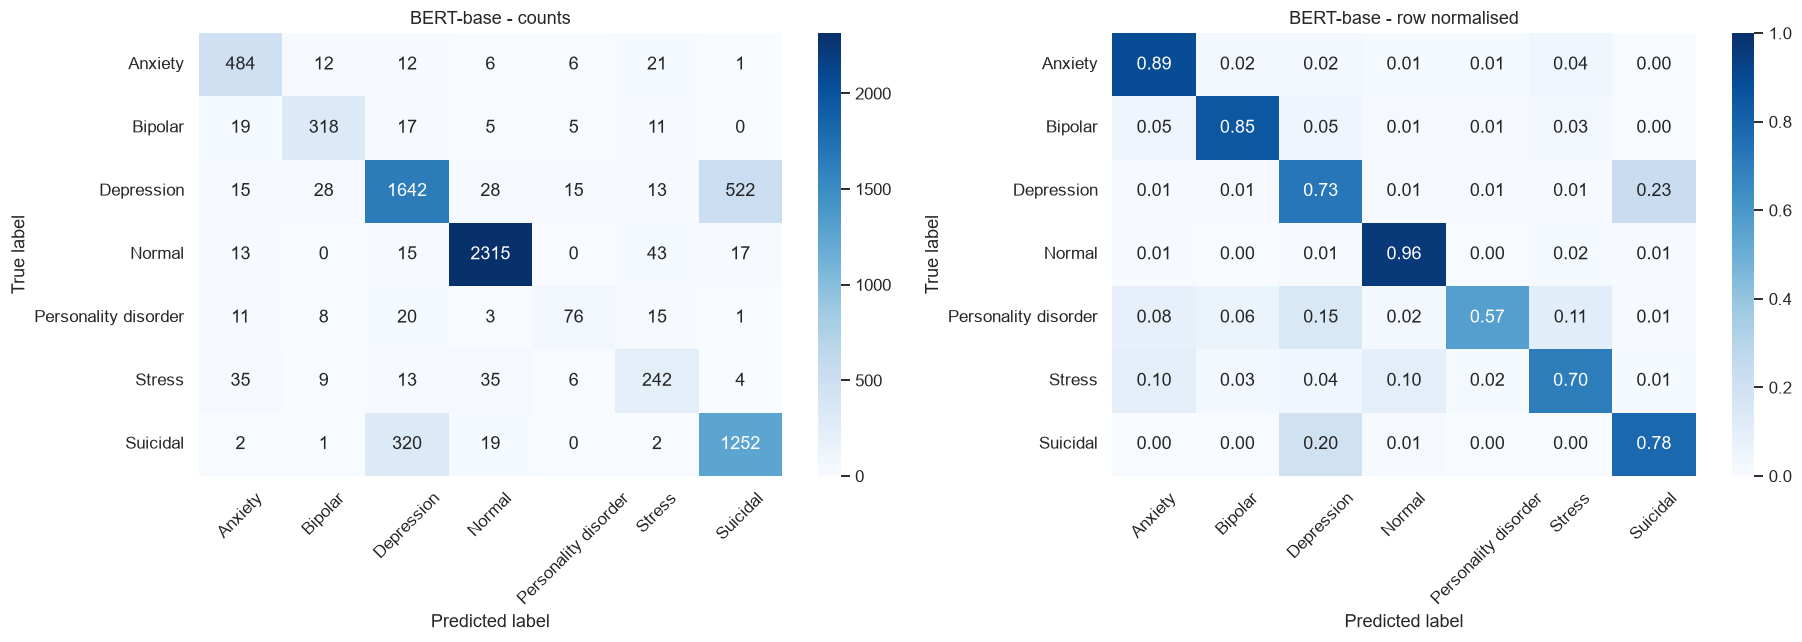

(0.8265639284315006, 0.7860075553734129)

In [49]:
bert_predictions = best_bert_probs.argmax(axis=1)
evaluate_model("BERT-base", y_test, bert_predictions, best_bert_probs,
               family="Transformer", notes=str(best_bert_config))

### 9.2 Additional transformer checkpoints


RoBERTa-base - roberta-base


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 11587.78it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.469809,0.478045,0.762407,0.809978
2,0.378601,0.449527,0.783744,0.822646
3,0.290155,0.466435,0.788563,0.826303


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.62it/s]


Training Loss,Validation Loss,Epoch,Macro F1,Accuracy
0.290155,0.466435,3,0.788563,0.826303


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.22it/s]


Validation macro F1: 0.7886 (7.5 minutes)

  RoBERTa-base
  Accuracy   : 0.833
  Macro F1   : 0.7909
  Weighted F1: 0.8334

                      precision    recall  f1-score   support

             Anxiety       0.85      0.89      0.87       542
             Bipolar       0.86      0.82      0.84       375
          Depression       0.78      0.79      0.79      2263
              Normal       0.97      0.95      0.96      2403
Personality disorder       0.61      0.62      0.61       134
              Stress       0.73      0.74      0.74       344
            Suicidal       0.74      0.73      0.74      1596

            accuracy                           0.83      7657
           macro avg       0.79      0.79      0.79      7657
        weighted avg       0.83      0.83      0.83      7657



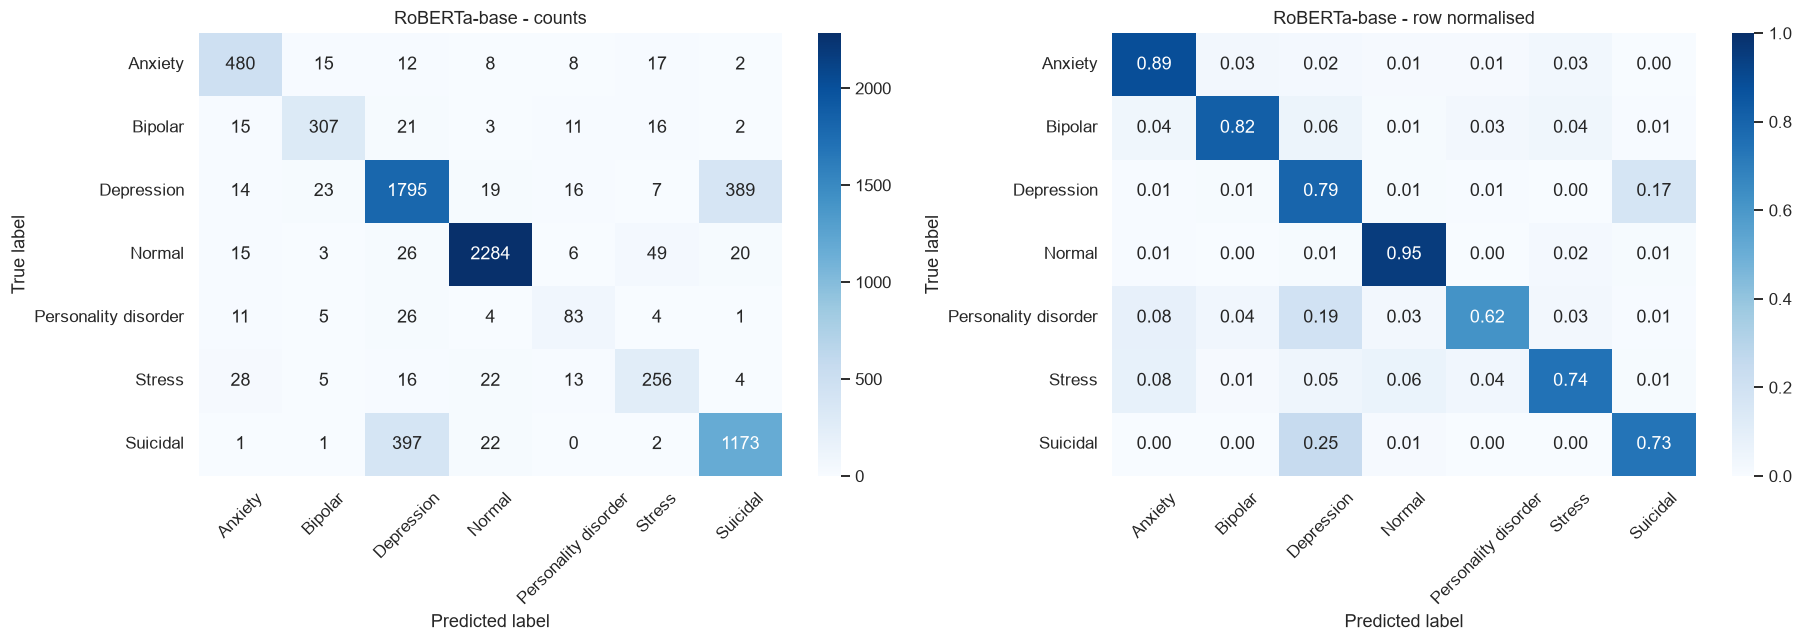


DeBERTa-v3-base - microsoft/deberta-v3-base


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 49491.79it/s]
[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING   

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,1.599146,1.602165,0.068248,0.313830
2,1.609120,1.598581,0.068248,0.313830


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.48it/s]


Training Loss,Validation Loss,Epoch,Macro F1,Accuracy
1.609120,1.602165,2,0.068248,0.313830


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.97it/s]


Validation macro F1: 0.0682 (7.5 minutes)

  DeBERTa-v3-base
  Accuracy   : 0.3138
  Macro F1   : 0.0682
  Weighted F1: 0.1499

                      precision    recall  f1-score   support

             Anxiety       0.00      0.00      0.00       542
             Bipolar       0.00      0.00      0.00       375
          Depression       0.00      0.00      0.00      2263
              Normal       0.31      1.00      0.48      2403
Personality disorder       0.00      0.00      0.00       134
              Stress       0.00      0.00      0.00       344
            Suicidal       0.00      0.00      0.00      1596

            accuracy                           0.31      7657
           macro avg       0.04      0.14      0.07      7657
        weighted avg       0.10      0.31      0.15      7657



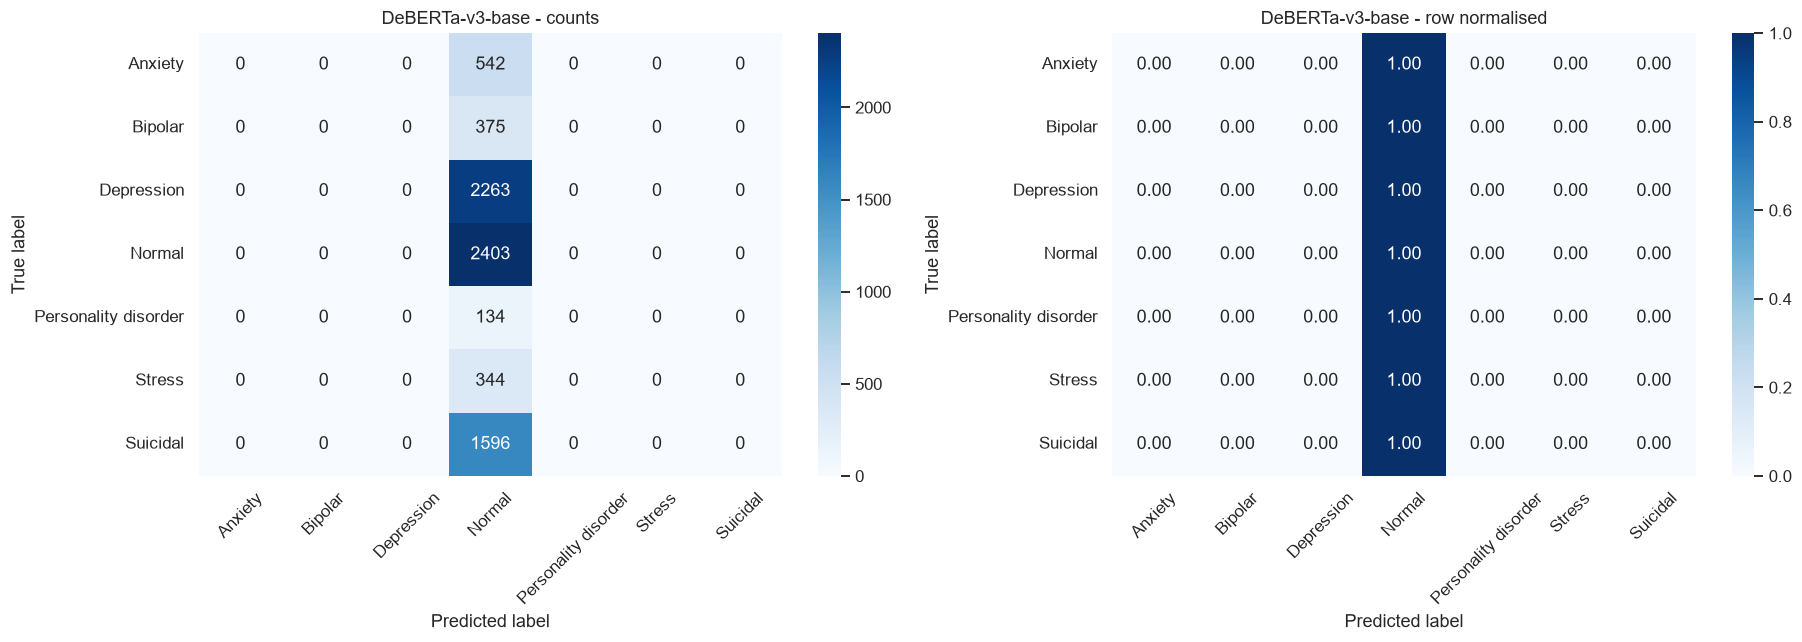

In [50]:
extra_models = {
    "RoBERTa-base": {"checkpoint": "roberta-base", "learning_rate": 2e-5, "batch_size": 16},
    "DeBERTa-v3-base": {"checkpoint": "microsoft/deberta-v3-base",
                        "learning_rate": 2e-5, "batch_size": 16},
}

if CONFIG["run_extra_tf"]:
    for nickname, settings in extra_models.items():
        settings = dict(settings)
        checkpoint = settings.pop("checkpoint")

        print()
        print("=" * 62)
        print(nickname, "-", checkpoint)
        print("=" * 62)

        try:
            start_time = time.time()
            run_name = nickname.replace("-", "_")
            val_f1, test_probs = run_transformer(checkpoint, run_name, **settings)

            print("Validation macro F1:", round(val_f1, 4),
                  f"({(time.time() - start_time) / 60:.1f} minutes)")

            evaluate_model(nickname, y_test, test_probs.argmax(axis=1), test_probs,
                           family="Transformer")
        except Exception as error:
            print("Skipped", nickname, ":", type(error).__name__, error)
            print("If this is a tokenizer error, run the install cell and restart the kernel.")
            gc.collect()
            torch.cuda.empty_cache()
else:
    print("Extra transformers disabled in CONFIG.")

## 10. Ensemble and significance testing

In [52]:
print("Models with stored probabilities:")
for model_name, probabilities in TEST_PROB.items():
    print(f"  {model_name:22s} {probabilities.shape}")

best_per_family = {}
for record in RESULTS:
    model_name = record["Model"]
    family = record["Family"]

    if family == "Baseline" or model_name not in TEST_PROB:
        continue

    if family not in best_per_family:
        best_per_family[family] = record
    elif record["Macro_F1"] > best_per_family[family]["Macro_F1"]:
        best_per_family[family] = record

ensemble_members = [record["Model"] for record in best_per_family.values()]

print()
print("Ensemble members, one per family:")
for member in ensemble_members:
    print("  ", member)

Models with stored probabilities:
  Naive_Bayes            (7657, 7)
  Logistic_Regression    (7657, 7)
  Random_Forest          (7657, 7)
  Linear_SVC             (7657, 7)
  SimpleRNN              (7657, 7)
  GRU                    (7657, 7)
  LSTM                   (7657, 7)
  Bi-SimpleRNN           (7657, 7)
  Bi-GRU                 (7657, 7)
  Bi-LSTM                (7657, 7)
  BERT-base              (7657, 7)
  RoBERTa-base           (7657, 7)
  DeBERTa-v3-base        (7657, 7)

Ensemble members, one per family:
   Logistic_Regression
   Bi-GRU
   RoBERTa-base



  Ensemble_SoftVote
  Accuracy   : 0.8287
  Macro F1   : 0.7879
  Weighted F1: 0.83

                      precision    recall  f1-score   support

             Anxiety       0.85      0.88      0.87       542
             Bipolar       0.85      0.84      0.85       375
          Depression       0.81      0.76      0.78      2263
              Normal       0.96      0.94      0.95      2403
Personality disorder       0.64      0.62      0.63       134
              Stress       0.61      0.80      0.69       344
            Suicidal       0.72      0.76      0.74      1596

            accuracy                           0.83      7657
           macro avg       0.78      0.80      0.79      7657
        weighted avg       0.83      0.83      0.83      7657



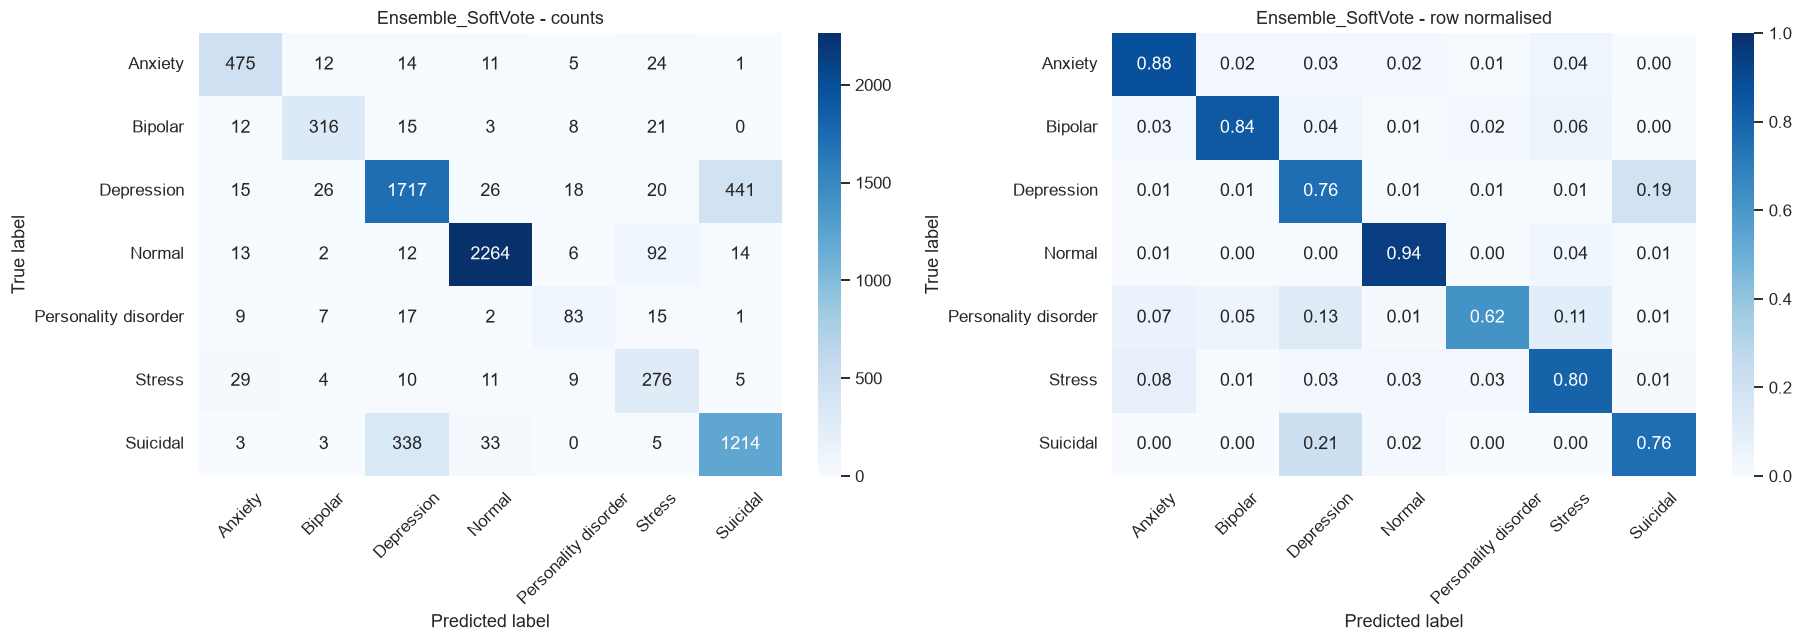

In [53]:
if len(ensemble_members) >= 2:
    member_probabilities = [TEST_PROB[name] for name in ensemble_members]
    ensemble_probs = np.mean(member_probabilities, axis=0)
    ensemble_pred = ensemble_probs.argmax(axis=1)

    evaluate_model("Ensemble_SoftVote", y_test, ensemble_pred, ensemble_probs,
                   family="Ensemble", notes=" + ".join(ensemble_members))
else:
    print("At least two families with probabilities are needed to build an ensemble.")

In [54]:
from scipy.stats import binomtest

if "Ensemble_SoftVote" in TEST_PRED:
    single_model_records = [record for record in RESULTS
                            if record["Family"] != "Ensemble"
                            and record["Model"] in TEST_PRED]
    best_single = max(single_model_records, key=lambda record: record["Macro_F1"])

    ensemble_pred = TEST_PRED["Ensemble_SoftVote"]
    single_pred = TEST_PRED[best_single["Model"]]

    ensemble_correct = ensemble_pred == y_test
    single_correct = single_pred == y_test

    single_only = int(np.sum(~ensemble_correct & single_correct))
    ensemble_only = int(np.sum(ensemble_correct & ~single_correct))

    print("McNemar test: Ensemble against", best_single["Model"])
    print("  Ensemble right, single wrong:", ensemble_only)
    print("  Single right, ensemble wrong:", single_only)

    total_disagreements = single_only + ensemble_only
    if total_disagreements > 0:
        p_value = binomtest(min(single_only, ensemble_only),
                            total_disagreements, 0.5).pvalue
        print("  Two sided p value           :", f"{p_value:.3g}")
        if p_value < 0.05:
            print("  The difference is statistically significant at alpha = 0.05.")
        else:
            print("  The difference is not statistically significant at alpha = 0.05.")
    else:
        print("  The two models never disagree, so no test is possible.")
else:
    print("No ensemble was built, so there is nothing to test.")

McNemar test: Ensemble against RoBERTa-base
  Ensemble right, single wrong: 262
  Single right, ensemble wrong: 295
  Two sided p value           : 0.175
  The difference is not statistically significant at alpha = 0.05.


## 11. Results summary

In [55]:
results_df = pd.DataFrame(RESULTS)
results_df = results_df.sort_values("Macro_F1", ascending=False).reset_index(drop=True)

score_columns = ["Accuracy", "Macro_F1", "Weighted_F1"]
results_df[score_columns] = results_df[score_columns].round(4)

results_df.to_csv(OUT / "tables" / f"all_results_{SPLIT_PROTOCOL}.csv", index=False)
display(results_df)

best_row = results_df.iloc[0]
worst_row = results_df[results_df["Family"] != "Baseline"].iloc[-1]

print("Best performing model :", best_row["Model"],
      "with macro F1", best_row["Macro_F1"])
print("Worst performing model:", worst_row["Model"],
      "with macro F1", worst_row["Macro_F1"])

,Model,Family,Protocol,Accuracy,Macro_F1,Weighted_F1,Notes
0,RoBERTa-base,Transformer,A,0.8330,0.7909,0.8334,
1,Ensemble_SoftVote,Ensemble,A,0.8287,0.7879,0.8300,Logistic_Regression + Bi-GRU + RoBERTa-base
2,BERT-base,Transformer,A,0.8266,0.7860,0.8263,"{'learning_rate': 3e-05, 'batch_size': 16}"
3,Bi-GRU,Recurrent,A,0.7631,0.7097,0.7693,
4,GRU,Recurrent,A,0.7609,0.7034,0.7648,
5,Bi-LSTM,Recurrent,A,0.7651,0.7023,0.7695,
6,Logistic_Regression,Classical,A,0.7468,0.6847,0.7472,
7,Linear_SVC,Classical,A,0.7583,0.6847,0.7512,
8,LSTM,Recurrent,A,0.7449,0.6665,0.7497,
9,Random_Forest,Classical,A,0.7239,0.6290,0.7138,


Best performing model : RoBERTa-base with macro F1 0.7909
Worst performing model: DeBERTa-v3-base with macro F1 0.0682


The standard error below shows how much two accuracy scores must differ before the gap between
them means anything. Differences smaller than the printed threshold should not be described as
one model beating another.

In [56]:
n_test = len(y_test)
best_accuracy = results_df["Accuracy"].max()
standard_error = np.sqrt(best_accuracy * (1 - best_accuracy) / n_test)

print("Test set size                :", n_test)
print("Standard error on accuracy   :", f"+/- {standard_error:.4f}")
print("95 percent confidence margin :", f"+/- {1.96 * standard_error:.4f}")
print()
print("Accuracy differences smaller than", round(2 * 1.96 * standard_error, 3),
      "cannot be distinguished from noise.")

Test set size                : 7657
Standard error on accuracy   : +/- 0.0043
95 percent confidence margin : +/- 0.0084

Accuracy differences smaller than 0.017 cannot be distinguished from noise.


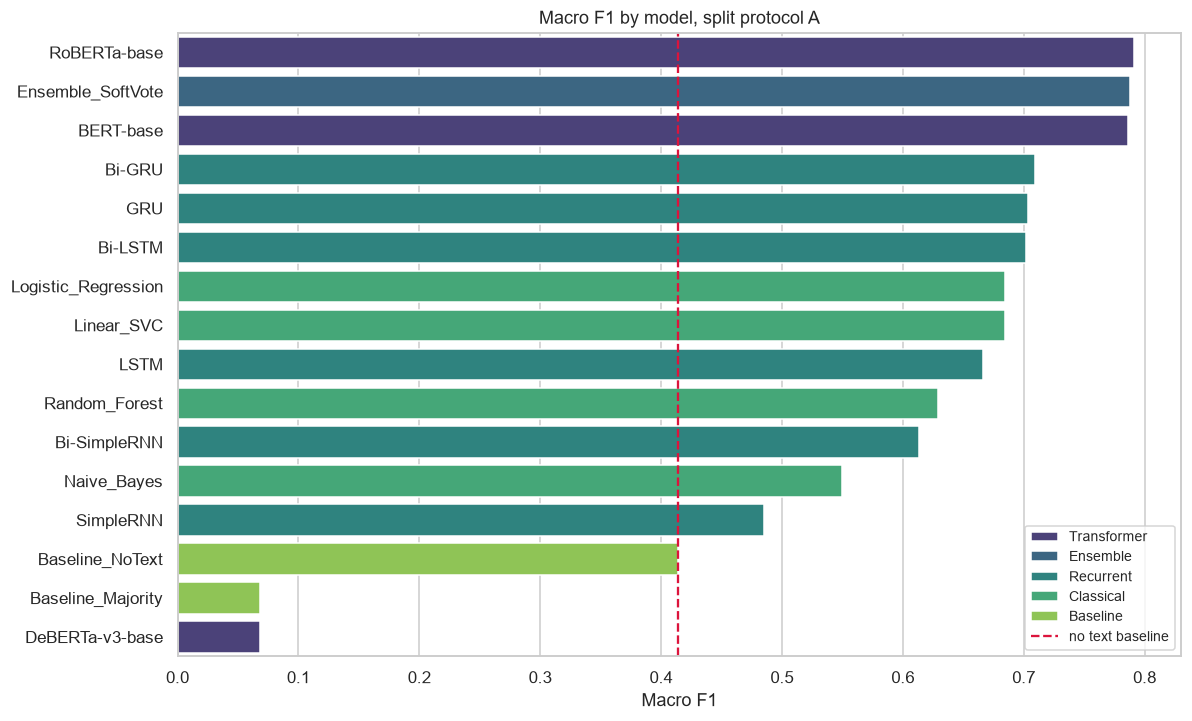

In [57]:
fig, axis = plt.subplots(figsize=(11, max(5, 0.42 * len(results_df))))

sns.barplot(data=results_df, y="Model", x="Macro_F1", hue="Family",
            dodge=False, palette="viridis", ax=axis)

if "Baseline_NoText" in results_df["Model"].values:
    baseline_score = results_df.loc[
        results_df["Model"] == "Baseline_NoText", "Macro_F1"].values[0]
    axis.axvline(baseline_score, color="crimson", linestyle="--",
                 linewidth=1.5, label="no text baseline")

axis.set_title(f"Macro F1 by model, split protocol {SPLIT_PROTOCOL}")
axis.set_xlabel("Macro F1")
axis.set_ylabel("")
axis.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig(OUT / "figures" / f"model_comparison_{SPLIT_PROTOCOL}.png", bbox_inches="tight")
plt.show()

### 11.1 Error analysis

In [58]:
best_model_name = results_df.iloc[0]["Model"]
best_predictions = TEST_PRED[best_model_name]

matrix = confusion_matrix(y_test, best_predictions, labels=range(N_CLASSES))
row_totals = np.clip(matrix.sum(axis=1, keepdims=True), 1, None)
matrix_normalised = matrix.astype(float) / row_totals

confusion_pairs = []
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        if i != j:
            confusion_pairs.append({
                "True": CLASSES[i],
                "Predicted": CLASSES[j],
                "Count": int(matrix[i, j]),
                "Rate": round(float(matrix_normalised[i, j]), 4),
            })

confusion_df = pd.DataFrame(confusion_pairs)
confusion_df = confusion_df.sort_values("Count", ascending=False).head(10)

print("Most frequent confusions for", best_model_name)
display(confusion_df)

Most frequent confusions for RoBERTa-base


,True,Predicted,Count,Rate
38,Suicidal,Depression,397,0.2487
17,Depression,Suicidal,389,0.1719
22,Normal,Stress,49,0.0204
30,Stress,Anxiety,28,0.0814
26,Personality disorder,Depression,26,0.1940
20,Normal,Depression,26,0.0108
13,Depression,Bipolar,23,0.0102
33,Stress,Normal,22,0.0640
39,Suicidal,Normal,22,0.0138
7,Bipolar,Depression,21,0.0560


In [59]:
wrong_indices = np.where(best_predictions != y_test)[0]
rng = np.random.default_rng(SEED)
sample_size = min(8, len(wrong_indices))
sampled_indices = rng.choice(wrong_indices, size=sample_size, replace=False)

error_df = pd.DataFrame({
    "True": label_encoder.inverse_transform(y_test[sampled_indices]),
    "Predicted": label_encoder.inverse_transform(best_predictions[sampled_indices]),
    "Statement": test_df["statement"].values[sampled_indices],
})
error_df["Statement"] = error_df["Statement"].astype(str).str.slice(0, 220)
error_df.to_csv(OUT / "tables" / "error_examples.csv", index=False)

pd.set_option("display.max_colwidth", 240)
display(error_df)
pd.set_option("display.max_colwidth", 120)

,True,Predicted,Statement
0,Suicidal,Depression,"I do not want to work on myself, idc about myself, I do not want to love myself. I hate myself and it will always be like this. I refuse to make any step towards bettering myself, I hope I end up dead in a fucking ditch"
1,Stress,Personality disorder,People pleasing sucks I hate when I have this constant need to make other people happy who couldn't give the slightest shit about me. Sometimes I would not be able to sleep or work until I know that they are happy knowin
2,Depression,Normal,i wa on 0 mg of hydroxyzine and i felt like it just wasn t doing anything so my doctor switched me today
3,Suicidal,Depression,"I have been changing numbers constantly just lately among other stuff I have been doing or not doing due to this feelings that I got during a very toxic relationship, I was doin better before it but the shame and guilt I"
4,Depression,Suicidal,"i feel so alone. if I am not going to work, then i do not hear or speak to anyone even when i reach out to people. I have realized the only way to make friends is to go drinking which has in turn made me absolutely hate"
5,Depression,Suicidal,Well after years of this bullshit I honestly believe am going to die alone and forgetten. Even when their are times when I try to reach out that broken side of me tells me to give up no one wants me around. Even when som
6,Suicidal,Depression,"Alot of noise in my head, alot of people rejecting me for reasons and for no reasons, feel stuck where iam and I cannot escape. What else better than disappear? Feeling that I am going to disappear makes me feel good"
7,Depression,Anxiety,"Comorbidity -Multiple Diagnosis For the first time after a long standing build up of intense anxiety and depression, I sought out for help, diagnosis, and medication.\n\nI was overwhelmed with what I got from 4 professiona"


## 12. Saving artifacts

In [60]:
import joblib

joblib.dump(tfidf, OUT / "models" / "tfidf_vectorizer.pkl")
joblib.dump(label_encoder, OUT / "models" / "label_encoder.pkl")
joblib.dump(best_classical["Logistic_Regression"], OUT / "models" / "best_logreg.pkl")

with open(OUT / "models" / "seq_vocab.json", "w", encoding="utf-8") as f:
    json.dump(word2idx, f)

run_summary = {
    "config": {key: str(value) for key, value in CONFIG.items()},
    "split_protocol": SPLIT_PROTOCOL,
    "seed": SEED,
    "classes": CLASSES,
    "n_train": len(train_df),
    "n_val": len(val_df),
    "n_test": len(test_df),
    "fast_mode": FAST_MODE,
}

with open(OUT / "models" / "run_config.json", "w", encoding="utf-8") as f:
    json.dump(run_summary, f, indent=2)

print("All artifacts saved under", OUT.resolve())
print()

for path in sorted(OUT.rglob("*")):
    if path.is_file():
        size_kb = path.stat().st_size / 1024
        print(f"  {path.relative_to(OUT)}  ({size_kb:.0f} KB)")

All artifacts saved under C:\ML\outputs

  figures\class_distribution.png  (27 KB)
  figures\cm_BERT-base.png  (119 KB)
  figures\cm_Bi-GRU.png  (124 KB)
  figures\cm_Bi-LSTM.png  (126 KB)
  figures\cm_Bi-SimpleRNN.png  (129 KB)
  figures\cm_DeBERTa-v3-base.png  (107 KB)
  figures\cm_Ensemble_SoftVote.png  (120 KB)
  figures\cm_GRU.png  (124 KB)
  figures\cm_Linear_SVC.png  (122 KB)
  figures\cm_Logistic_Regression.png  (125 KB)
  figures\cm_LSTM.png  (125 KB)
  figures\cm_Naive_Bayes.png  (124 KB)
  figures\cm_Random_Forest.png  (122 KB)
  figures\cm_RoBERTa-base.png  (121 KB)
  figures\cm_SimpleRNN.png  (129 KB)
  figures\length_by_class.png  (34 KB)
  figures\model_comparison_A.png  (56 KB)
  figures\top_tokens_per_class.png  (122 KB)
  models\bert_config_1\config.json  (1 KB)
  models\bert_config_1\model.safetensors  (427709 KB)
  models\bert_config_1\tokenizer.json  (695 KB)
  models\bert_config_1\tokenizer_config.json  (0 KB)
  models\bert_config_1\training_args.bin  (5 KB)
  mod